# v5 — Expanding moments, freeze streaks, amplitude

v4 scored a **finished** run. Here statistics **update every sample**, and an alarm is a critical change in the run so far — not a CSV label.

Three complementary views, all causal and per-run:

1. **Expanding moments** — mean / sd / skew / kurtosis of samples `{1,…,t}`.
2. **Differences** — `x_t - x_{t-1}`. A **freeze** is a streak of near-zero diffs (sensor stuck, as in a flat `xmeas_13` while the rest of the plant still moves).
3. **Amplitude** — peak-to-peak of a short recent window vs that sensor's usual early range. If the band grows 5 → 10 → 20 → 30, the envelope is no longer healthy.

**Careful first, easier later.** Thresholds start high (few samples, do not trust a short freeze or a slightly wider band) and ease toward looser values as `t` grows. Yellow / red still replace each other on a sample; a quiet run has no band.

**Corpus.** 21,000 unique runs. Train 500 samples, test 960. This notebook scores **`N_RUNS` random runs** (default 1,000, seed 42) for TPR/FPR vs CSV `fault_status`, and plots **all `xmeas_*` channels** for **`N_PLOT` random runs** (default 2). The detector never reads `faultNumber` / `fault_status` when it decides.


In [62]:
from __future__ import annotations

import logging
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Patch

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)

log = logging.getLogger("v5_stat")
if not log.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter("%(asctime)s  %(levelname)-7s  %(message)s", datefmt="%H:%M:%S"))
    log.addHandler(handler)
    log.setLevel(logging.INFO)
    log.propagate = False

CSV_PATH = Path("te_process.csv")
CATALOG_PATH = Path("run_moments_s1_500.csv")
CHUNKSIZE = 250_000
META_COLS = ["faultNumber", "simulationRun", "sample", "source", "fault_status"]
TRAIN_SAMPLES = 500
TEST_SAMPLES = 960
N_RUNS = 1000  # scored for TPR / FPR; change this to draw more or fewer
N_PLOT = 2  # full measurement grids for this many scored runs
SPLIT_SEED = 42
SAMPLE_CACHE = Path(f"v5_sample{N_RUNS}_runs_s{SPLIT_SEED}_native.csv")
SUMMARY_CACHE = Path(f"v5_eval{N_RUNS}_s{SPLIT_SEED}_summary.csv")
PLOT_SENSOR = "xmeas_7"
PLOT_DIFF_SENSOR = "xmeas_13"  # freeze / envelope example
PLOT_SENSORS = [f"xmeas_{i}" for i in (1, 7, 9, 13, 18, 21)]

MIN_T = 8
BURNIN = 20
SENSOR_Q = 0.90

# Moment z-gates: strict at burn-in, easier by sample EASE_T1.
YELLOW_Z0, YELLOW_Z1 = 5.0, 2.8
RED_Z0, RED_Z1 = 8.0, 4.8

# Freeze: extra near-zero diffs beyond that sensor's own burn-in streak.
FREEZE_Q = 0.75
FREEZE_FRAC = 0.02
FREEZE_LEN_Y0, FREEZE_LEN_Y1 = 14, 5
FREEZE_LEN_R0, FREEZE_LEN_R1 = 22, 9

# Local peak-to-peak window vs early usual range (measurements only).
AMP_WINDOW = 16
AMP_LOG = 0.45
AMP_Y0, AMP_Y1 = 3.2, 2.05
AMP_R0, AMP_R1 = 4.8, 3.1
AMP_N_Y0, AMP_N_Y1 = 5, 3
AMP_N_R0, AMP_N_R1 = 9, 5

EASE_T1 = 300

YELLOW = "#E0B000"
RED = "#C0392B"

log.info("csv         %s", CSV_PATH.resolve())
log.info("exists      %s", CSV_PATH.exists())
log.info("window      train 1–%s  test 1–%s", TRAIN_SAMPLES, TEST_SAMPLES)
log.info("this pass   %s random runs  seed=%s  plot %s of them", N_RUNS, SPLIT_SEED, N_PLOT)
log.info("burn-in     %s samples; thresholds ease until t=%s", BURNIN, EASE_T1)
log.info("moment z    yellow %s→%s  red %s→%s", YELLOW_Z0, YELLOW_Z1, RED_Z0, RED_Z1)
log.info("freeze len  yellow +%s→+%s  red +%s→+%s  (vs burn-in streak)", FREEZE_LEN_Y0, FREEZE_LEN_Y1, FREEZE_LEN_R0, FREEZE_LEN_R1)
log.info("amplitude   window=%s  yellow ×%s→×%s  (log-t allowance)", AMP_WINDOW, AMP_Y0, AMP_Y1)


16:58:32  INFO     csv         /Users/ob/Projects/hackathon_csv/data_processing/te_process.csv
16:58:32  INFO     exists      True
16:58:32  INFO     window      train 1–500  test 1–960
16:58:32  INFO     this pass   1000 random runs  seed=42  plot 2 of them
16:58:32  INFO     burn-in     20 samples; thresholds ease until t=300
16:58:32  INFO     moment z    yellow 5.0→2.8  red 8.0→4.8
16:58:32  INFO     freeze len  yellow +14→+5  red +22→+9  (vs burn-in streak)
16:58:32  INFO     amplitude   window=16  yellow ×3.2→×2.05  (log-t allowance)


## 1. Draw runs and stream their rows

Pick `N_RUNS` keys uniformly from the 21,000-run catalog (change `N_RUNS` in the setup cell), then stream the CSV once and keep those trajectories at **native length** (train 1–500, test 1–960). Cached so re-runs skip the 15M-row scan. Figures below use **`N_PLOT` random runs** and every measurement channel (`xmeas_*`).


In [63]:
def sensor_columns(columns) -> list[str]:
    return [c for c in columns if str(c).startswith("xmeas_") or str(c).startswith("xmv_")]


def compact_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "faultNumber" in out.columns:
        out["faultNumber"] = out["faultNumber"].astype(np.int16)
    if "simulationRun" in out.columns:
        out["simulationRun"] = out["simulationRun"].astype(np.int16)
    if "sample" in out.columns:
        out["sample"] = out["sample"].astype(np.int16)
    if "source" in out.columns:
        out["source"] = out["source"].astype(str)
    if "fault_status" in out.columns:
        out["fault_status"] = out["fault_status"].astype(str)
    return out


def native_len(source) -> int:
    return TEST_SAMPLES if str(source) == "test" else TRAIN_SAMPLES


def in_native_window(df: pd.DataFrame) -> pd.Series:
    sample = df["sample"].astype(int)
    cap = np.where(df["source"].astype(str).eq("test"), TEST_SAMPLES, TRAIN_SAMPLES)
    return sample.ge(1) & sample.le(cap)


def load_run_catalog() -> pd.DataFrame:
    if CATALOG_PATH.exists():
        cat = pd.read_csv(CATALOG_PATH, usecols=["source", "faultNumber", "simulationRun"])
        log.info("catalog     %s  runs=%s", CATALOG_PATH.name, f"{len(cat):,}")
        return compact_frame(cat)
    keys = []
    header = pd.read_csv(CSV_PATH, nrows=0)
    usecols = [c for c in META_COLS if c in header.columns]
    for chunk in pd.read_csv(CSV_PATH, usecols=usecols, chunksize=CHUNKSIZE):
        live = compact_frame(chunk.loc[in_native_window(chunk)])
        keys.append(live[["source", "faultNumber", "simulationRun"]].drop_duplicates())
    cat = pd.concat(keys, ignore_index=True).drop_duplicates()
    log.info("catalog     streamed  runs=%s", f"{len(cat):,}")
    return cat


def draw_run_keys(n: int = N_RUNS, seed: int = SPLIT_SEED) -> pd.DataFrame:
    cat = load_run_catalog()
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(cat), size=min(n, len(cat)), replace=False)
    picked = cat.iloc[idx].copy().reset_index(drop=True)
    return picked.sort_values(["source", "faultNumber", "simulationRun"]).reset_index(drop=True)


def stream_selected_runs(keys: pd.DataFrame) -> pd.DataFrame:
    key_df = (
        keys[["source", "faultNumber", "simulationRun"]]
        .drop_duplicates()
        .assign(
            source=lambda d: d["source"].astype(str),
            faultNumber=lambda d: d["faultNumber"].astype(int),
            simulationRun=lambda d: d["simulationRun"].astype(int),
        )
    )
    keyset = set(zip(key_df["source"], key_df["faultNumber"], key_df["simulationRun"]))
    header = pd.read_csv(CSV_PATH, nrows=0)
    sensors = sensor_columns(header.columns)
    usecols = [c for c in META_COLS + sensors if c in header.columns]
    parts: list[pd.DataFrame] = []
    have: set[tuple] = set()
    counts: dict[tuple, int] = {}
    t0 = time.time()
    for i, chunk in enumerate(pd.read_csv(CSV_PATH, usecols=usecols, chunksize=CHUNKSIZE), start=1):
        live = compact_frame(chunk.loc[in_native_window(chunk)])
        sub = live.merge(key_df, on=["source", "faultNumber", "simulationRun"], how="inner")
        if len(sub):
            parts.append(sub)
            for key, n_rows in sub.groupby(["source", "faultNumber", "simulationRun"], sort=False).size().items():
                k = (str(key[0]), int(key[1]), int(key[2]))
                counts[k] = counts.get(k, 0) + int(n_rows)
            have = set(counts)
        if i % 10 == 0:
            log.info("stream      chunk %s  keys=%s/%s  %.1fs", i, len(have), len(keyset), time.time() - t0)
        if have >= keyset and all(counts.get(k, 0) >= native_len(k[0]) for k in keyset):
            log.info("stream      all keys complete at chunk %s  %.1fs", i, time.time() - t0)
            break
    out = pd.concat(parts, ignore_index=True)
    return out.sort_values(["source", "faultNumber", "simulationRun", "sample"]).reset_index(drop=True)


def load_sample_runs() -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    keys = draw_run_keys()
    if SAMPLE_CACHE.exists():
        raw = compact_frame(pd.read_csv(SAMPLE_CACHE))
        raw = raw.loc[in_native_window(raw)]
        got = (
            raw[["source", "faultNumber", "simulationRun"]]
            .drop_duplicates()
            .sort_values(["source", "faultNumber", "simulationRun"])
            .reset_index(drop=True)
        )
        want = keys.sort_values(["source", "faultNumber", "simulationRun"]).reset_index(drop=True)
        want_n = int(want["source"].map(native_len).sum())
        if got.equals(want) and got.shape[0] == N_RUNS and len(raw) == want_n:
            log.info("cache hit   %s  rows=%s", SAMPLE_CACHE.name, f"{len(raw):,}")
            sensors = sensor_columns(raw.columns)
            return keys, raw, sensors
        log.info("cache miss  keys changed — restreaming")
    raw = stream_selected_runs(keys)
    raw.to_csv(SAMPLE_CACHE, index=False)
    log.info("cache write %s  rows=%s", SAMPLE_CACHE.name, f"{len(raw):,}")
    return keys, raw, sensor_columns(raw.columns)


keys, runs, SENSOR_COLS = load_sample_runs()
plot_sensor = PLOT_SENSOR if PLOT_SENSOR in SENSOR_COLS else SENSOR_COLS[0]
log.info("sensors     %s", len(SENSOR_COLS))
log.info("plot sensor %s", plot_sensor)
log.info(
    "run length  %s",
    runs.groupby(["source", "faultNumber", "simulationRun"])["sample"].size().value_counts().sort_index().to_dict(),
)
print(f"{N_RUNS} random runs (labels unused by the detector; used later for TPR/FPR)")
display(keys.assign(faultNumber=keys["faultNumber"].astype(int), simulationRun=keys["simulationRun"].astype(int)).head(20))
print(f"... {len(keys)} keys total")


16:58:32  INFO     catalog     run_moments_s1_500.csv  runs=21,000
16:58:33  INFO     cache hit   v5_sample1000_runs_s42_native.csv  rows=726,320
16:58:33  INFO     sensors     52
16:58:33  INFO     plot sensor xmeas_7
16:58:33  INFO     run length  {500: 508, 960: 492}


1000 random runs (labels unused by the detector; used later for TPR/FPR)


,source,faultNumber,simulationRun
0,test,0,89
1,test,0,99
2,test,0,110
3,test,0,111
4,test,0,134
5,test,0,145
6,test,0,154
7,test,0,160
8,test,0,206
9,test,0,245


... 1000 keys total


## 2. Expanding mean, sd, skew, kurtosis

For a run matrix `X` of shape `(T, n_sensors)`, at row `t` the four numbers are pandas `mean / std / skew / kurt` of samples `1…t` (excess kurtosis, bias-corrected). Sample 1 has only a mean; sd starts at 2, skew at 3, kurtosis at 4.


In [64]:
def expanding_moments(X: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Moments of samples 1..t for every t. Matches pandas expanding()."""
    ex = pd.DataFrame(np.asarray(X, dtype=np.float64)).expanding(min_periods=1)
    return (
        ex.mean().to_numpy(np.float64),
        ex.std(ddof=1).to_numpy(np.float64),
        ex.skew().to_numpy(np.float64),
        ex.kurt().to_numpy(np.float64),
    )


# Check against a full-window pandas row on one sensor of the first run.
_probe = next(iter(runs.groupby(["source", "faultNumber", "simulationRun"], sort=True)))[1]
_x = _probe.sort_values("sample")[plot_sensor].to_numpy(np.float64)
_mean, _sd, _skew, _kurt = expanding_moments(_x[:, None])
_s = pd.Series(_x)
assert np.isclose(_mean[-1, 0], _s.mean())
assert np.isclose(_sd[-1, 0], _s.std(ddof=1))
assert np.isclose(_skew[-1, 0], _s.skew())
assert np.isclose(_kurt[-1, 0], _s.kurt())
log.info("expanding   pandas match on %s  n=%s", plot_sensor, len(_x))


16:58:33  INFO     expanding   pandas match on xmeas_7  n=960


## 3. Agnostic yellow / red

No labels. Each run calibrates on its first 20 samples, then three scores can raise an alarm. **Red replaces yellow** on that sample. The plant-level flag is the max of the three.

**Ease.** At sample $t$, a smoothstep $u(t)\in[0,1]$ runs from burn-in to sample 300. Every gate interpolates from a **strict** start value to an **easier** late value. Short freezes and modest envelope growth are ignored early; the same evidence is enough later.

### Moments

Studentize the new sample against yesterday's expanding mean/sd. RMS of the four Gaussian influence functions (mean, sd, skew, kurtosis), then the 90th percentile across all 52 channels. Yellow / red on that z-score, with two consecutive samples needed for yellow.

### Differences (freeze)

$d_t = x_t - x_{t-1}$. A channel is *frozen* when $|d_t|$ is tiny vs that channel's own 75th-percentile step in the burn-in (composition analyzers that hold for one sample are calibrated out). Alarm if the **streak of frozen diffs** exceeds the burn-in max streak plus a length that shrinks with $t$. One stuck measurement is enough. Manipulated variables (`xmv_*`) are ignored here — a quiet valve is not a frozen sensor.

### Amplitude (max envelope width)

Usual range = median peak-to-peak of a 16-sample window during burn-in. Current range = the same window ending at $t$. Score = (current / usual) / $(1 + 0.45\log(t/20))$, so a slowly explored range is allowed. If the band grows 5 → 10 → 20 → 30, the ratio outruns that allowance. Needs several `xmeas_*` channels at once (not one noisy tag).


In [65]:
MOMENT_NAMES = np.array(["mean", "sd", "skew", "kurt"])


def ease_01(t, t0: int = BURNIN, t1: int = EASE_T1) -> np.ndarray:
    x = np.asarray(t, dtype=np.float64)
    u = np.clip((x - t0) / max(t1 - t0, 1), 0.0, 1.0)
    return u * u * (3.0 - 2.0 * u)


def lerp(a: float, b: float, u):
    return a + (b - a) * u


def meas_columns(cols) -> list[str]:
    return [c for c in cols if str(c).startswith("xmeas_")]


def moment_surprises(X: np.ndarray, mean: np.ndarray, sd: np.ndarray) -> dict[str, np.ndarray]:
    T, n_s = X.shape
    z = np.full((T, n_s), np.nan)
    floor = np.maximum(1e-6 * np.abs(mean[:-1]), 1e-8)
    past_sd = np.maximum(sd[:-1], floor)
    with np.errstate(invalid="ignore", over="ignore", divide="ignore"):
        z[1:] = np.clip((X[1:] - mean[:-1]) / past_sd, -20.0, 20.0)
        return {
            "mean": np.abs(z),
            "sd": np.abs(z**2 - 1.0) / np.sqrt(2.0),
            "skew": np.abs(z**3) / np.sqrt(15.0),
            "kurt": np.abs(z**4 - 3.0) / np.sqrt(96.0),
        }


def combined_score(surprises: dict[str, np.ndarray]) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    stack = np.stack([surprises[k] for k in MOMENT_NAMES], axis=0)
    with np.errstate(invalid="ignore", divide="ignore"):
        sensor_score = np.sqrt(np.nanmean(np.where(np.isfinite(stack), stack**2, np.nan), axis=0))
    T = sensor_score.shape[0]
    score = np.full(T, np.nan)
    ok = np.isfinite(sensor_score).any(axis=1)
    if ok.any():
        score[ok] = np.nanquantile(sensor_score[ok], SENSOR_Q, axis=1)
    q4 = np.full((4, T), np.nan)
    if ok.any():
        q4[:, ok] = np.nanquantile(stack[:, ok, :], SENSOR_Q, axis=2)
    q4_fill = np.where(np.isfinite(q4), q4, -np.inf)
    mom_id = np.argmax(q4_fill, axis=0).astype(np.int8)
    return score, mom_id, sensor_score


def calibrate(score: np.ndarray) -> tuple[float, float]:
    cal = score[MIN_T - 1 : BURNIN]
    mu = float(np.nanmedian(cal))
    sig = float(1.4826 * np.nanmedian(np.abs(cal - mu)))
    if not np.isfinite(mu):
        mu = 0.0
    if not np.isfinite(sig) or sig < 0.25:
        sig = 0.25
    return mu, sig


def rolling_ptp(X: np.ndarray, window: int) -> np.ndarray:
    frame = pd.DataFrame(X)
    return frame.rolling(window, min_periods=window).max().to_numpy(np.float64) - frame.rolling(
        window, min_periods=window
    ).min().to_numpy(np.float64)


def freeze_streaks(X: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Causal near-zero diff streaks. Returns abs diffs, streak, burn-in max streak, eps."""
    T, S = X.shape
    absd = np.full((T, S), np.nan)
    absd[1:] = np.abs(X[1:] - X[:-1])
    q = np.nanquantile(absd[1:BURNIN], FREEZE_Q, axis=0)
    medx = np.nanmedian(np.abs(X[:BURNIN]), axis=0)
    eps = np.maximum(FREEZE_FRAC * q, 1e-6 * np.maximum(medx, 1.0))
    frozen = np.zeros((T, S), dtype=bool)
    frozen[1:] = absd[1:] < eps
    streak = np.zeros((T, S), dtype=np.int16)
    for t in range(1, T):
        streak[t] = np.where(frozen[t], streak[t - 1] + 1, 0)
    l0 = streak[1:BURNIN].max(axis=0).astype(np.int16)
    return absd, streak, l0, eps


def amplitude_ratio(X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Local peak-to-peak / usual early range, divided by a log-t allowance."""
    T = X.shape[0]
    local = rolling_ptp(X, AMP_WINDOW)
    base = np.nanmedian(local[AMP_WINDOW - 1 : BURNIN], axis=0)
    base = np.maximum(base, 1e-12)
    t = np.arange(1, T + 1, dtype=np.float64)
    allow = 1.0 + AMP_LOG * np.log(np.maximum(t, BURNIN) / BURNIN)
    with np.errstate(invalid="ignore", divide="ignore"):
        ratio = (local / base) / allow[:, None]
    return local, ratio


def detect_alarms(score: np.ndarray, mu: float, sig: float, streak: np.ndarray, l0: np.ndarray, amp_ratio: np.ndarray) -> dict:
    T = len(score)
    idx = np.arange(T)
    u = ease_01(idx)
    y_z = lerp(YELLOW_Z0, YELLOW_Z1, u)
    r_z = lerp(RED_Z0, RED_Z1, u)
    y_len = np.rint(lerp(FREEZE_LEN_Y0, FREEZE_LEN_Y1, u)).astype(int)
    r_len = np.rint(lerp(FREEZE_LEN_R0, FREEZE_LEN_R1, u)).astype(int)
    y_amp = lerp(AMP_Y0, AMP_Y1, u)
    r_amp = lerp(AMP_R0, AMP_R1, u)
    y_n = np.rint(lerp(AMP_N_Y0, AMP_N_Y1, u)).astype(int)
    r_n = np.rint(lerp(AMP_N_R0, AMP_N_R1, u)).astype(int)

    z = (score - mu) / sig
    z[:BURNIN] = np.nan
    mom = np.zeros(T, dtype=np.int8)
    raw = np.zeros(T, dtype=np.int8)
    finite = np.isfinite(z)
    raw[finite & (z >= y_z)] = 1
    raw[finite & (z >= r_z)] = 2
    for t in range(BURNIN, T):
        if raw[t] == 2:
            mom[t] = 2
        elif raw[t] == 1 and raw[t - 1] >= 1:
            mom[t] = 1

    frz = np.zeros(T, dtype=np.int8)
    extra = streak - l0[None, :]
    max_extra = extra.max(axis=1) if extra.size else np.zeros(T)
    which_fr = extra.argmax(axis=1) if extra.size else np.zeros(T, dtype=int)
    for t in range(BURNIN, T):
        if max_extra[t] >= r_len[t]:
            frz[t] = 2
        elif max_extra[t] >= y_len[t]:
            frz[t] = 1

    amp = np.zeros(T, dtype=np.int8)
    finite_r = np.isfinite(amp_ratio)
    q90 = np.full(T, np.nan)
    if finite_r.any():
        q90 = np.where(
            finite_r.any(axis=1),
            np.nanquantile(np.where(finite_r, amp_ratio, np.nan), 0.90, axis=1),
            np.nan,
        )
    n_hot = np.nansum(amp_ratio >= 2.0, axis=1).astype(int)
    which_amp = np.nanargmax(np.where(finite_r, amp_ratio, -np.inf), axis=1) if amp_ratio.size else np.zeros(T, dtype=int)
    for t in range(BURNIN, T):
        if not np.isfinite(q90[t]):
            continue
        if q90[t] >= r_amp[t] and n_hot[t] >= r_n[t]:
            amp[t] = 2
        elif q90[t] >= y_amp[t] and n_hot[t] >= y_n[t]:
            amp[t] = 1

    level = np.maximum(np.maximum(mom, frz), amp)
    reason = np.array(["", "moment", "freeze", "amp"], dtype=object)
    who = np.argmax(np.stack([np.zeros(T, dtype=np.int8), mom, frz, amp], axis=0), axis=0).astype(np.int8)
    who = np.where(level == 0, 0, who)
    return {
        "z": z,
        "level": level,
        "mom": mom,
        "freeze": frz,
        "amp": amp,
        "reason": reason[who],
        "y_z": y_z,
        "r_z": r_z,
        "amp_q90": q90,
        "freeze_extra": max_extra,
        "which_fr": which_fr,
        "which_amp": which_amp,
    }


def alarm_spans(level: np.ndarray, samples: np.ndarray) -> list[tuple[float, float, str]]:
    spans = []
    t = 0
    T = len(level)
    while t < T:
        if level[t] == 0:
            t += 1
            continue
        val = int(level[t])
        t0 = t
        while t < T and level[t] == val:
            t += 1
        color = RED if val == 2 else YELLOW
        spans.append((float(samples[t0]), float(samples[t - 1]), color))
    return spans


def n_events(level: np.ndarray, val: int) -> int:
    prev = np.concatenate([[0], level[:-1]])
    return int(np.sum((level == val) & (prev != val)))


def first_sample(mask: np.ndarray, samples: np.ndarray) -> int | None:
    idx = np.flatnonzero(mask)
    return int(samples[idx[0]]) if len(idx) else None


def analyze_run(frame: pd.DataFrame) -> dict:
    frame = frame.sort_values("sample")
    samples = frame["sample"].to_numpy(np.int16)
    X = frame[SENSOR_COLS].to_numpy(np.float64)
    meas_idx = [i for i, c in enumerate(SENSOR_COLS) if str(c).startswith("xmeas_")]
    X_meas = X[:, meas_idx]
    mean, sd, skew, kurt = expanding_moments(X)
    surprises = moment_surprises(X, mean, sd)
    score, mom_id, sensor_score = combined_score(surprises)
    mu, sig = calibrate(score)
    absd, streak, l0, eps = freeze_streaks(X_meas)
    local_amp, amp_ratio = amplitude_ratio(X_meas)
    det = detect_alarms(score, mu, sig, streak, l0, amp_ratio)
    alarm = det["level"] > 0
    if alarm.any():
        mom_counts = pd.Series(MOMENT_NAMES[mom_id[alarm]]).value_counts().to_dict()
        reason_counts = pd.Series(det["reason"][alarm]).value_counts().to_dict()
    else:
        mom_counts = {}
        reason_counts = {}
    return {
        "source": str(frame["source"].iloc[0]),
        "faultNumber": int(frame["faultNumber"].iloc[0]),
        "simulationRun": int(frame["simulationRun"].iloc[0]),
        "fault_status": str(frame["fault_status"].iloc[0]),
        "samples": samples,
        "X": X,
        "mean": mean,
        "sd": sd,
        "skew": skew,
        "kurt": kurt,
        "score": score,
        "mu": mu,
        "sig": sig,
        "mom_id": mom_id,
        "mom_counts": mom_counts,
        "reason_counts": reason_counts,
        "sensor_score": sensor_score,
        "absd_meas": absd,
        "streak": streak,
        "local_amp": local_amp,
        "amp_ratio": amp_ratio,
        "meas_idx": meas_idx,
        "spans": alarm_spans(det["level"], samples),
        **det,
    }


def top_reason(a: dict) -> str:
    rc = a["reason_counts"]
    return max(rc, key=rc.get) if rc else ""


def summarize_run(a: dict) -> dict:
    n_y = int((a["level"] == 1).sum())
    n_r = int((a["level"] == 2).sum())
    ev_y = n_events(a["level"], 1)
    ev_r = n_events(a["level"], 2)
    z_tail = a["z"][BURNIN:]
    return {
        "source": a["source"],
        "IDV": a["faultNumber"],
        "run": a["simulationRun"],
        "n_samples": int(len(a["samples"])),
        "csv_status": a["fault_status"],
        "n_yellow": n_y,
        "n_red": n_r,
        "events_yellow": ev_y,
        "events_red": ev_r,
        "first_yellow": first_sample(a["level"] == 1, a["samples"]),
        "first_red": first_sample(a["level"] == 2, a["samples"]),
        "n_freeze": int((a["freeze"] > 0).sum()),
        "n_amp": int((a["amp"] > 0).sum()),
        "n_moment": int((a["mom"] > 0).sum()),
        "top_reason": top_reason(a),
        "z_max": round(float(np.nanmax(z_tail)), 2) if np.isfinite(z_tail).any() else np.nan,
        "alarm": int((ev_y + ev_r) > 0),
    }


def pick_plot_keys(keys: pd.DataFrame, n: int = N_PLOT, seed: int = SPLIT_SEED) -> set[tuple]:
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(keys), size=min(n, len(keys)), replace=False)
    sub = keys.iloc[idx]
    return set(
        zip(sub["source"].astype(str), sub["faultNumber"].astype(int), sub["simulationRun"].astype(int))
    )


plot_keyset = pick_plot_keys(keys)
plotted: list[dict] = []
rows: list[dict] = []
t0 = time.time()
groups = runs.groupby(["source", "faultNumber", "simulationRun"], sort=True)
n_groups = groups.ngroups
for i, ((src, fn, rn), g) in enumerate(groups, start=1):
    a = analyze_run(g)
    rows.append(summarize_run(a))
    if (str(src), int(fn), int(rn)) in plot_keyset:
        plotted.append(a)
    if i % 50 == 0 or i == n_groups:
        log.info("scored      %s / %s  %.1fs", i, n_groups, time.time() - t0)

plotted.sort(key=lambda a: (a["source"], a["faultNumber"], a["simulationRun"]))

MEAS_COLS = meas_columns(SENSOR_COLS)
summary = pd.DataFrame(rows)
summary.to_csv(SUMMARY_CACHE, index=False)
log.info("summary     %s  rows=%s", SUMMARY_CACHE.name, f"{len(summary):,}")
log.info("runs scored %s", len(summary))
log.info("any alarm  %s / %s", int(summary.alarm.sum()), len(summary))
log.info(
    "by channel freeze=%s amp=%s moment=%s",
    int((summary.n_freeze > 0).sum()),
    int((summary.n_amp > 0).sum()),
    int((summary.n_moment > 0).sum()),
)
print("Detector does not use csv_status. alarm = at least one yellow or red event.")
print(f"Showing first 20 of {len(summary)} scored runs; full table is `summary`.")
display(summary.head(20))


/var/folders/hw/zh08vgx16815gz89lgw4z6qw0000gn/T/ipykernel_95916/1654064083.py:36: RuntimeWarning: Mean of empty slice
  sensor_score = np.sqrt(np.nanmean(np.where(np.isfinite(stack), stack**2, np.nan), axis=0))
/Users/ob/Projects/hackathon_csv/data_processing/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
16:58:36  INFO     scored      50 / 1000  3.5s
16:58:40  INFO     scored      100 / 1000  6.9s
16:58:43  INFO     scored      150 / 1000  10.3s
16:58:47  INFO     scored      200 / 1000  13.7s
16:58:50  INFO     scored      250 / 1000  17.2s
16:58:54  INFO     scored      300 / 1000  20.7s
16:58:57  INFO     scored      350 / 1000  24.1s
16:59:01  INFO     scored      400 / 1000  27.6s
16:59:04  INFO     scored      450 / 1000  31.1s
16:59:07  INFO     scored      500 / 1000  34.4s
16:59:09  INFO     scored      550 / 1000  36.2s
16:59:11  INFO     scored      600 / 1000  38.2s
16:59:13  INFO

Detector does not use csv_status. alarm = at least one yellow or red event.
Showing first 20 of 1000 scored runs; full table is `summary`.


,source,IDV,run,n_samples,csv_status,n_yellow,n_red,events_yellow,events_red,first_yellow,first_red,n_freeze,n_amp,n_moment,top_reason,z_max,alarm
0,test,0,89,960,normal,5,1,4,1,840.0,873.0,0,0,6,moment,5.75,1
1,test,0,99,960,normal,1,0,1,0,204.0,NaN,0,0,1,moment,3.95,1
2,test,0,110,960,normal,1,0,1,0,729.0,NaN,1,0,0,freeze,3.42,1
3,test,0,111,960,normal,0,0,0,0,NaN,NaN,0,0,0,,2.39,0
4,test,0,134,960,normal,0,0,0,0,NaN,NaN,0,0,0,,1.27,0
5,test,0,145,960,normal,2,0,2,0,450.0,NaN,2,0,0,freeze,1.18,1
6,test,0,154,960,normal,0,0,0,0,NaN,NaN,0,0,0,,2.86,0
7,test,0,160,960,normal,6,2,4,2,288.0,293.0,0,0,8,moment,7.42,1
8,test,0,206,960,normal,1,0,1,0,797.0,NaN,0,0,1,moment,4.22,1
9,test,0,245,960,normal,0,0,0,0,NaN,NaN,0,0,0,,3.23,0


## 4. TPR / FPR vs CSV `fault_status`

The detector still does not read labels. After scoring, we compare each run to `fault_status`:

| CSV status | required | error if |
| --- | --- | --- |
| **faulty** | at least one yellow or red **event** | miss (FN) |
| **normal** | zero yellow and zero red events | false alarm (FP) |

**TPR** = TP / (TP+FN) on faulty runs. **FPR** = FP / (FP+TN) on normal runs. `alarm` is `events_yellow + events_red > 0` (same as any yellow/red sample).


N_RUNS=1000  seed=42
pred = any yellow or red event   label = csv_status


,runs,n_faulty,n_normal,TPR,FPR,Youden,TP,FN,FP,TN
all,1000,948,52,0.707,0.404,0.303,670,278,21,31
train,508,479,29,0.647,0.379,0.268,310,169,11,18
test,492,469,23,0.768,0.435,0.333,360,109,10,13
train_faulty (TPR),479,479,0,0.647,nan,nan,310,169,0,0
train_normal (FPR),29,0,29,nan,0.379,nan,0,0,11,18
test_faulty (TPR),469,469,0,0.768,nan,nan,360,109,0,0
test_normal (FPR),23,0,23,nan,0.435,nan,0,0,10,13



TPR / FPR by source × IDV  (IDV 0 is the normal class)


,source,IDV,runs,n_faulty,n_normal,TPR,FPR
0,test,0,23,0,23,nan,0.435
1,test,1,21,21,0,1.000,nan
2,test,2,18,18,0,1.000,nan
3,test,3,29,29,0,0.379,nan
4,test,4,30,30,0,0.500,nan
5,test,5,34,34,0,1.000,nan
6,test,6,26,26,0,1.000,nan
7,test,7,21,21,0,1.000,nan
8,test,8,14,14,0,1.000,nan
9,test,9,24,24,0,0.542,nan


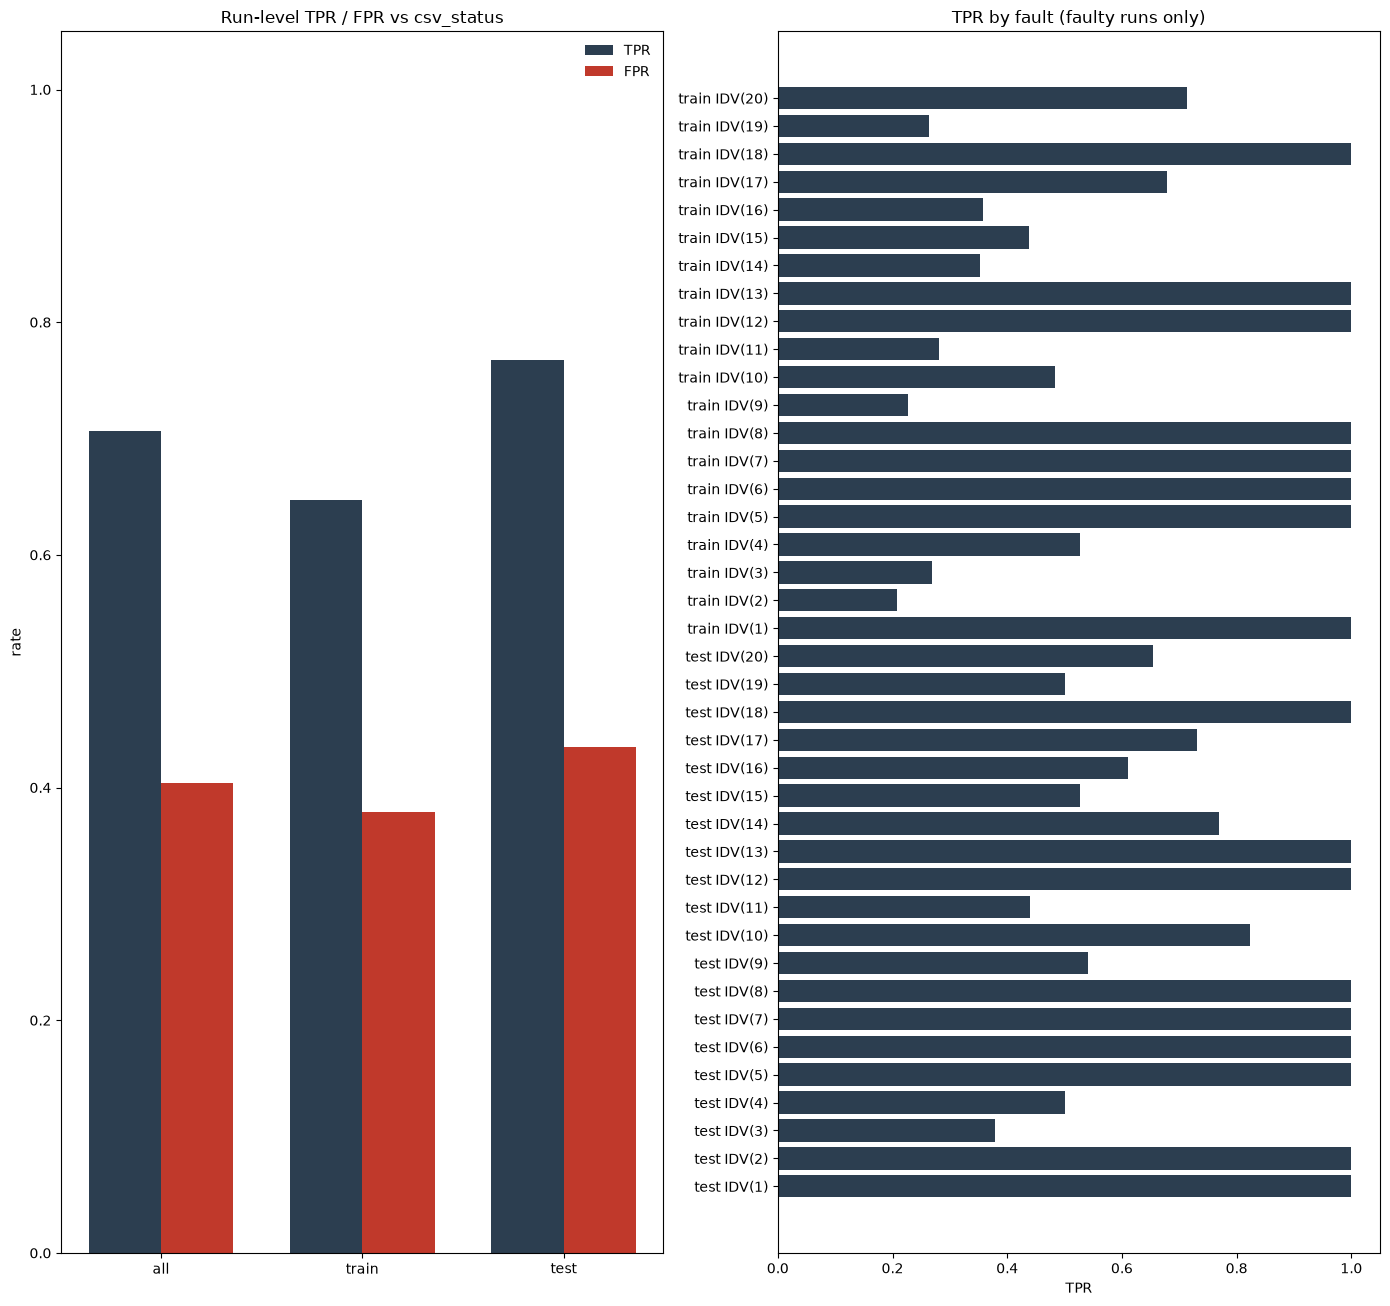

overall  TPR=70.7%  FPR=40.4%  TP=670 FN=278 FP=21 TN=31


In [66]:
def detection_table(frame: pd.DataFrame) -> dict:
    y = frame["csv_status"].eq("faulty").to_numpy()
    yhat = (frame["events_yellow"] + frame["events_red"] > 0).to_numpy()
    tp = int((y & yhat).sum())
    fn = int((y & ~yhat).sum())
    fp = int((~y & yhat).sum())
    tn = int((~y & ~yhat).sum())
    n_pos = tp + fn
    n_neg = fp + tn
    tpr = tp / n_pos if n_pos else np.nan
    fpr = fp / n_neg if n_neg else np.nan
    return {
        "runs": int(len(frame)),
        "n_faulty": int(n_pos),
        "n_normal": int(n_neg),
        "TPR": tpr,
        "FPR": fpr,
        "Youden": (tpr - fpr) if np.isfinite(tpr) and np.isfinite(fpr) else np.nan,
        "TP": tp,
        "FN": fn,
        "FP": fp,
        "TN": tn,
    }


blocks = {
    "all": summary,
    "train": summary.loc[summary["source"].eq("train")],
    "test": summary.loc[summary["source"].eq("test")],
    "train_faulty (TPR)": summary.loc[summary["source"].eq("train") & summary["csv_status"].eq("faulty")],
    "train_normal (FPR)": summary.loc[summary["source"].eq("train") & summary["csv_status"].eq("normal")],
    "test_faulty (TPR)": summary.loc[summary["source"].eq("test") & summary["csv_status"].eq("faulty")],
    "test_normal (FPR)": summary.loc[summary["source"].eq("test") & summary["csv_status"].eq("normal")],
}
rates = pd.DataFrame({name: detection_table(frame) for name, frame in blocks.items() if len(frame)}).T
print(f"N_RUNS={N_RUNS}  seed={SPLIT_SEED}")
print("pred = any yellow or red event   label = csv_status")
display(
    rates.style.format(
        {
            "TPR": "{:.3f}",
            "FPR": "{:.3f}",
            "Youden": "{:.3f}",
            "runs": "{:.0f}",
            "n_faulty": "{:.0f}",
            "n_normal": "{:.0f}",
            "TP": "{:.0f}",
            "FN": "{:.0f}",
            "FP": "{:.0f}",
            "TN": "{:.0f}",
        }
    )
)

by_idv_rows = []
for (src, idv), g in summary.groupby(["source", "IDV"], sort=True):
    faulty = g["csv_status"].eq("faulty")
    by_idv_rows.append(
        {
            "source": src,
            "IDV": int(idv),
            "runs": len(g),
            "n_faulty": int(faulty.sum()),
            "n_normal": int((~faulty).sum()),
            "TPR": float(g.loc[faulty, "alarm"].mean()) if faulty.any() else np.nan,
            "FPR": float(g.loc[~faulty, "alarm"].mean()) if (~faulty).any() else np.nan,
        }
    )
by_idv = pd.DataFrame(by_idv_rows)
print("\nTPR / FPR by source × IDV  (IDV 0 is the normal class)")
display(by_idv.style.format({"TPR": "{:.3f}", "FPR": "{:.3f}", "runs": "{:.0f}", "n_faulty": "{:.0f}", "n_normal": "{:.0f}"}))

fig, axes = plt.subplots(1, 2, figsize=(14, max(4.2, 0.28 * max(len(by_idv), 1) + 1.4)))
overview = rates.loc[rates.index.isin(["all", "train", "test"])]
x = np.arange(len(overview))
w = 0.36
axes[0].bar(x - w / 2, overview["TPR"].to_numpy(), w, color="#2C3E50", label="TPR")
axes[0].bar(x + w / 2, overview["FPR"].to_numpy(), w, color=RED, label="FPR")
axes[0].set_xticks(x, overview.index)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("rate")
axes[0].set_title("Run-level TPR / FPR vs csv_status")
axes[0].legend(frameon=False)

idv_tpr = by_idv.loc[by_idv["n_faulty"] > 0].copy()
idv_tpr["label"] = idv_tpr["source"] + " IDV(" + idv_tpr["IDV"].astype(str) + ")"
axes[1].barh(idv_tpr["label"], idv_tpr["TPR"], color="#2C3E50")
axes[1].set_xlim(0, 1.05)
axes[1].set_xlabel("TPR")
axes[1].set_title("TPR by fault (faulty runs only)")
fig.tight_layout()
plt.show()

all_rates = detection_table(summary)
print(
    f"overall  TPR={all_rates['TPR']:.1%}  FPR={all_rates['FPR']:.1%}  "
    f"TP={all_rates['TP']} FN={all_rates['FN']} FP={all_rates['FP']} TN={all_rates['TN']}"
)


## 5. Catalog detectors vs self-calibrated ticks (not mixed)

**Yes — the original five v2 rules still learn from train IDV(0)** (`faultNumber == 0`): min/max/mean/sd for `out_of_range` / `zscore_4sd` / `persist_4sd`, and labeled healthy vs faulty samples for `nb` / `fda`. That catalog is *not* this run.

`nb` and `fda` cannot drop that: they are supervised. The other three **can** run like v5 / v4 distribution logic — **one new sample tick at a time**, using only this run’s own past:

| suffix | what it knows at sample `t` |
| --- | --- |
| *(none)* / `_exp` | train IDV(0) catalog (v2) |
| **`_self`** | nothing from other runs. Tick `x_t` vs statistics of `{1,…,t−1}` (after this run’s burn-in) |

- **`zscore_4sd_self`**: `z_t = (x_t − μ_{t−1}) / σ_{t−1}` on each sensor; yellow if any `|z|≥4`, red if any `|z|≥6`
- **`persist_4sd_self`**: 5 of the last 8 ticks had a self z-score hit (7/8 → red)
- **`out_of_range_self`**: `x_t` outside this run’s **burn-in** min/max (samples 1–20)

Yellow / red stay **per method** and are never OR-ed into freeze / moment / amplitude. Same TPR/FPR rule as §4.


16:59:27  INFO     catalog hit  v5_catalog_idv0_stats.csv  n_idv0=235500  clf n=49600
16:59:27  INFO     clfs        FDA + GaussianNB fit  n=49,600  fault=9600
16:59:27  INFO     catalog score 50 / 1000  0.3s
16:59:27  INFO     catalog score 100 / 1000  0.5s
16:59:27  INFO     catalog score 150 / 1000  0.7s
16:59:28  INFO     catalog score 200 / 1000  1.0s
16:59:28  INFO     catalog score 250 / 1000  1.3s
16:59:28  INFO     catalog score 300 / 1000  1.5s
16:59:28  INFO     catalog score 350 / 1000  1.7s
16:59:29  INFO     catalog score 400 / 1000  2.0s
16:59:29  INFO     catalog score 450 / 1000  2.2s
16:59:29  INFO     catalog score 500 / 1000  2.5s
16:59:29  INFO     catalog score 550 / 1000  2.6s
16:59:29  INFO     catalog score 600 / 1000  2.8s
16:59:30  INFO     catalog score 650 / 1000  3.0s
16:59:30  INFO     catalog score 700 / 1000  3.1s
16:59:30  INFO     catalog score 750 / 1000  3.3s
16:59:30  INFO     catalog score 800 / 1000  3.5s
16:59:30  INFO     catalog score 850 / 10

Same 1,000 runs. Methods are NOT mixed into v5 yellow/red.
_self = no train IDV(0); tick t vs this run.  x_t / _exp = still fit on train IDV(0).  nb/fda need labels.


,runs,n_faulty,n_normal,TPR,FPR,Youden,TP,FN,FP,TN,kind,v2_TPR,v2_FPR_test,v2_Youden_test,vs_v5_Youden
method,,,,,,,,,,,,,,,
v5_combined,1000,948,52,0.707,0.404,0.303,670,278,21,31,v5 gates (this run only),nan,nan,nan,+0.000
out_of_range_self,1000,948,52,1.000,1.000,0.000,948,0,52,0,self: tick t vs this run 1…t-1,nan,nan,nan,-0.303
persist_4sd_self,1000,948,52,0.761,0.212,0.549,721,227,11,41,self: tick t vs this run 1…t-1,nan,nan,nan,+0.246
zscore_4sd_self,1000,948,52,0.942,0.788,0.154,893,55,41,11,self: tick t vs this run 1…t-1,nan,nan,nan,-0.149
out_of_range,1000,948,52,0.867,0.154,0.713,822,126,8,44,"catalog train IDV(0), sample x_t",0.855,0.000,0.855,+0.410
persist_4sd,1000,948,52,0.831,0.058,0.774,788,160,3,49,"catalog train IDV(0), sample x_t",0.824,0.062,0.762,+0.471
nb,1000,948,52,0.806,0.038,0.767,764,184,2,50,"catalog train IDV(0), sample x_t",0.800,0.106,0.694,+0.465
fda,1000,948,52,0.655,0.096,0.559,621,327,5,47,"catalog train IDV(0), sample x_t",0.820,0.398,0.422,+0.256
zscore_4sd,1000,948,52,0.890,0.250,0.640,844,104,13,39,"catalog train IDV(0), sample x_t",0.935,0.658,0.277,+0.337


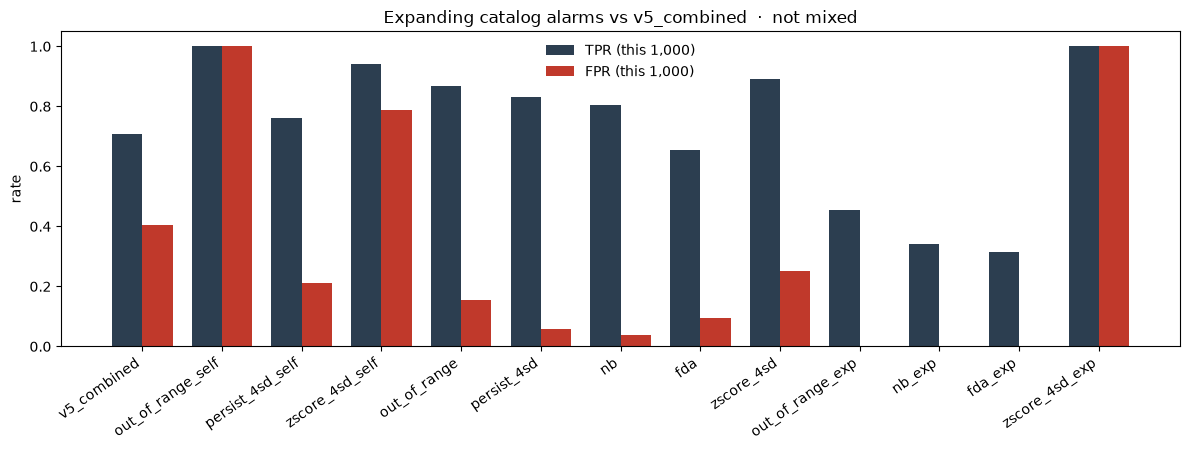


Youden = TPR − FPR.  vs_v5_Youden > 0  means that method is better than v5_combined on this draw.
                                                   kind    TPR    FPR  Youden  vs_v5_Youden
method                                                                                     
v5_combined                    v5 gates (this run only)  0.707  0.404   0.303         0.000
out_of_range_self        self: tick t vs this run 1…t-1  1.000  1.000   0.000        -0.303
persist_4sd_self         self: tick t vs this run 1…t-1  0.761  0.212   0.549         0.246
zscore_4sd_self          self: tick t vs this run 1…t-1  0.942  0.788   0.154        -0.149
out_of_range           catalog train IDV(0), sample x_t  0.867  0.154   0.713         0.410
persist_4sd            catalog train IDV(0), sample x_t  0.831  0.058   0.774         0.471
nb                     catalog train IDV(0), sample x_t  0.806  0.038   0.767         0.465
fda                    catalog train IDV(0), sample x_t  0.655  0.096   0

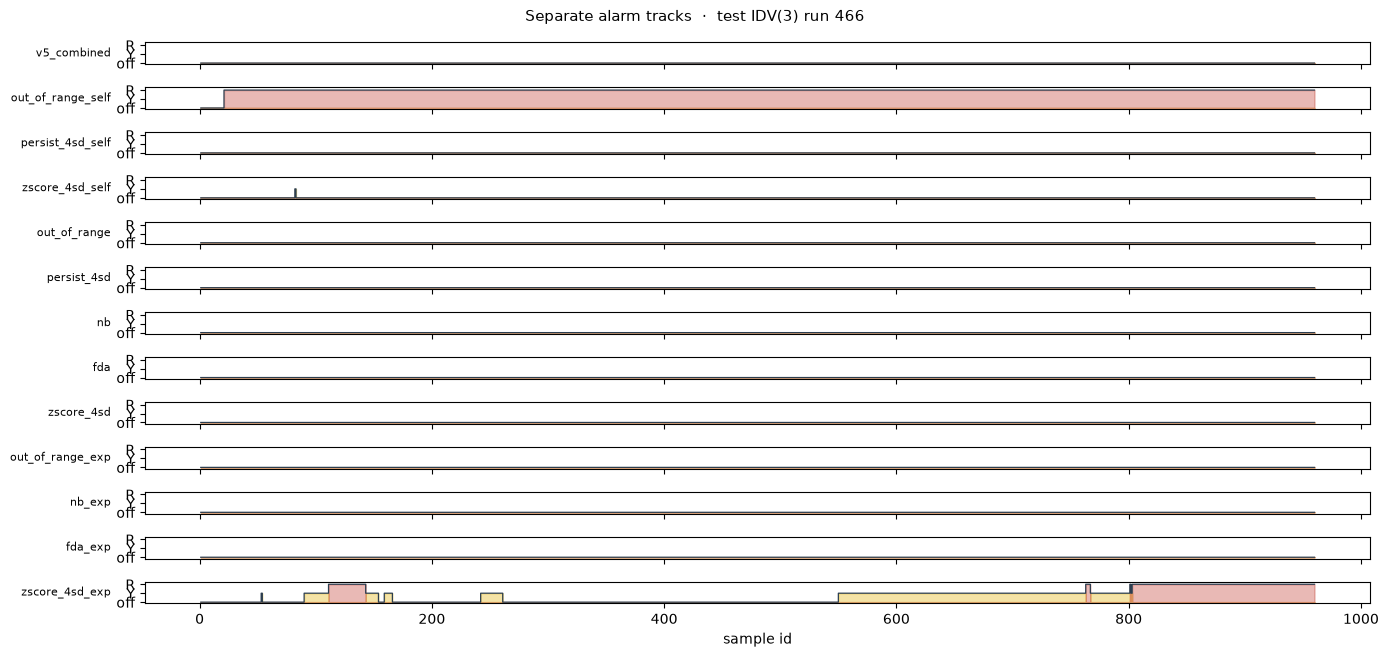

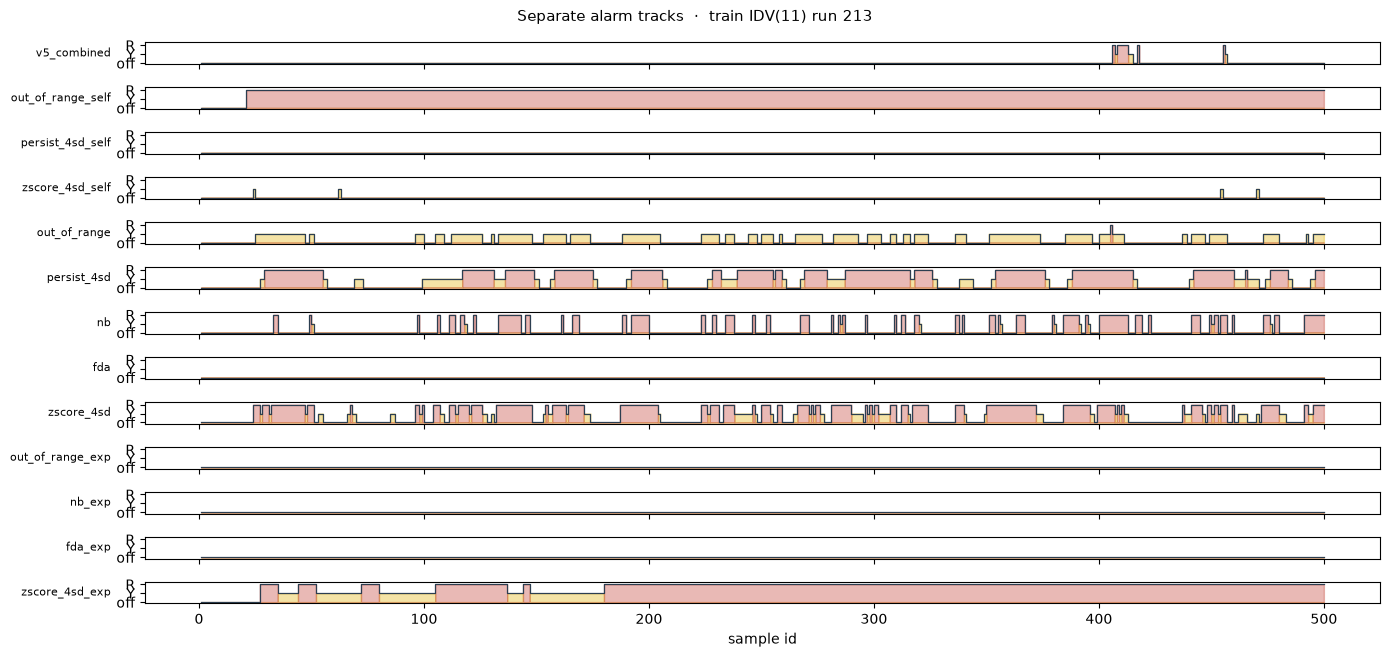

In [67]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

CATALOG_STATS_PATH = Path("v5_catalog_idv0_stats.csv")
CLF_CACHE_PATH = Path("v5_clf_train.npz")
CLF_NORMAL_MAX = 40_000
PERSIST_NEED, PERSIST_WIN = 5, 8
PERSIST_RED_NEED = 7
OOR_RED_SENSORS = 3
Z_YELLOW, Z_RED = 4.0, 6.0
CLF_RED_P = 0.90

V2_SHEET = pd.DataFrame(
    {
        "v2_TPR": [0.8553, 0.8242, 0.7996, 0.8203, 0.9348],
        "v2_FPR_test": [0.0000, 0.0620, 0.1060, 0.3980, 0.6580],
        "v2_Youden_test": [0.8553, 0.7622, 0.6936, 0.4223, 0.2768],
    },
    index=["out_of_range", "persist_4sd", "nb", "fda", "zscore_4sd"],
)


def _eval_key_frame() -> pd.DataFrame:
    return (
        keys[["source", "faultNumber", "simulationRun"]]
        .drop_duplicates()
        .assign(
            source=lambda d: d["source"].astype(str),
            faultNumber=lambda d: d["faultNumber"].astype(int),
            simulationRun=lambda d: d["simulationRun"].astype(int),
            _eval=np.int8(1),
        )
    )


def _not_eval(frame: pd.DataFrame, eval_keys: pd.DataFrame) -> pd.DataFrame:
    merged = frame.merge(eval_keys, on=["source", "faultNumber", "simulationRun"], how="left")
    return merged.loc[merged["_eval"].isna()].drop(columns=["_eval"])


def fit_catalog() -> dict:
    if CATALOG_STATS_PATH.exists() and CLF_CACHE_PATH.exists():
        st = pd.read_csv(CATALOG_STATS_PATH, index_col="sensor")
        if list(st.index) == list(SENSOR_COLS):
            blob = np.load(CLF_CACHE_PATH, allow_pickle=False)
            log.info(
                "catalog hit  %s  n_idv0=%s  clf n=%s",
                CATALOG_STATS_PATH.name,
                int(st["n"].iloc[0]),
                int(blob["y"].size),
            )
            return {"stats": st, "X_clf": blob["X"], "y_clf": blob["y"]}
        log.info("catalog miss  sensor list changed")

    eval_keys = _eval_key_frame()
    header = pd.read_csv(CSV_PATH, nrows=0)
    usecols = [c for c in META_COLS + SENSOR_COLS if c in header.columns]
    n = 0
    sumx = sumsq = minx = maxx = None
    idv0_parts: list[pd.DataFrame] = []
    idv0_n = 0
    fault_got: dict[int, pd.DataFrame] = {}
    fault_buf: dict[tuple, pd.DataFrame] = {}
    t0 = time.time()
    saw_train = False
    log.info("catalog     streaming train IDV(0) stats + FDA/NB labels (excludes the %s eval keys)", len(eval_keys))
    for i, chunk in enumerate(pd.read_csv(CSV_PATH, usecols=usecols, chunksize=CHUNKSIZE), start=1):
        train = compact_frame(chunk.loc[chunk["source"].astype(str).eq("train")])
        if train.empty:
            if saw_train and len(fault_got) == 20 and n > 0:
                log.info("catalog     train block finished at chunk %s  %.1fs", i, time.time() - t0)
                break
            continue
        saw_train = True
        train = _not_eval(train, eval_keys)
        n0 = train.loc[train["faultNumber"].astype(int).eq(0)]
        if len(n0):
            X = n0[SENSOR_COLS].to_numpy(np.float64)
            if sumx is None:
                sumx = np.nansum(X, axis=0)
                sumsq = np.nansum(X * X, axis=0)
                minx = np.nanmin(X, axis=0)
                maxx = np.nanmax(X, axis=0)
                n = int(X.shape[0])
            else:
                sumx += np.nansum(X, axis=0)
                sumsq += np.nansum(X * X, axis=0)
                minx = np.fmin(minx, np.nanmin(X, axis=0))
                maxx = np.fmax(maxx, np.nanmax(X, axis=0))
                n += int(X.shape[0])
            if idv0_n < CLF_NORMAL_MAX:
                take = n0.sample(n=min(len(n0), CLF_NORMAL_MAX - idv0_n), random_state=42)
                idv0_parts.append(take[SENSOR_COLS])
                idv0_n += len(take)
        part = train.loc[train["faultNumber"].astype(int).between(1, 20)]
        if len(part) and len(fault_got) < 20:
            for key, g in part.groupby(["source", "faultNumber", "simulationRun"], sort=False):
                fn = int(key[1])
                if fn in fault_got:
                    continue
                piece = g.reset_index(drop=True)
                if key in fault_buf:
                    piece = pd.concat([fault_buf.pop(key), piece], ignore_index=True)
                if len(piece) >= TRAIN_SAMPLES:
                    run = piece.iloc[:TRAIN_SAMPLES]
                    run = run.loc[run["sample"].astype(int) > BURNIN]
                    if len(run):
                        fault_got[fn] = run[SENSOR_COLS]
                else:
                    fault_buf[key] = piece
        if i % 10 == 0:
            log.info(
                "catalog     chunk %s  idv0_n=%s  fault IDVs=%s/20  %.1fs",
                i,
                f"{n:,}",
                len(fault_got),
                time.time() - t0,
            )

    mu = sumx / max(n, 1)
    pop = np.maximum(sumsq / max(n, 1) - mu**2, 0.0)
    sd = np.sqrt(pop * n / max(n - 1, 1))
    st = pd.DataFrame(
        {"n": n, "mean": mu, "sd": np.maximum(sd, 1e-12), "min": minx, "max": maxx},
        index=pd.Index(SENSOR_COLS, name="sensor"),
    )
    st.to_csv(CATALOG_STATS_PATH)
    X_n = pd.concat(idv0_parts, ignore_index=True).to_numpy(np.float64) if idv0_parts else np.zeros((0, len(SENSOR_COLS)))
    X_f = (
        pd.concat(fault_got.values(), ignore_index=True).to_numpy(np.float64)
        if fault_got
        else np.zeros((0, len(SENSOR_COLS)))
    )
    X_clf = np.vstack([X_n, X_f])
    y_clf = np.concatenate([np.zeros(len(X_n), dtype=np.int8), np.ones(len(X_f), dtype=np.int8)])
    np.savez(CLF_CACHE_PATH, X=X_clf, y=y_clf)
    log.info(
        "catalog write  idv0=%s  clf normal=%s fault=%s  IDVs=%s",
        f"{n:,}",
        f"{len(X_n):,}",
        f"{len(X_f):,}",
        sorted(fault_got),
    )
    return {"stats": st, "X_clf": X_clf, "y_clf": y_clf}


def rolling_count(hits: np.ndarray, win: int) -> np.ndarray:
    T = len(hits)
    out = np.zeros(T, dtype=np.int16)
    if T == 0:
        return out
    c = np.cumsum(np.r_[0, hits.astype(np.int32)])
    w = min(win, T)
    out[w - 1 :] = c[w:] - c[: T - w + 1]
    if w > 1:
        out[: w - 1] = c[1:w]
    return out


def raw_to_level(y_raw: np.ndarray, r_raw: np.ndarray, *, need_two: bool) -> np.ndarray:
    T = len(y_raw)
    level = np.zeros(T, dtype=np.int8)
    y = np.asarray(y_raw, dtype=bool)
    r = np.asarray(r_raw, dtype=bool)
    y[:BURNIN] = False
    r[:BURNIN] = False
    for t in range(BURNIN, T):
        if r[t]:
            level[t] = 2
        elif y[t] and (y[t - 1] if need_two else True):
            level[t] = 1
    return level


def fit_clfs(X: np.ndarray, y: np.ndarray) -> tuple:
    fda = Pipeline(
        [
            ("scale", StandardScaler()),
            ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
        ]
    )
    nb = Pipeline([("scale", StandardScaler()), ("clf", GaussianNB())])
    fda.fit(X, y)
    nb.fit(X, y)
    return fda, nb


def clf_scores(model, X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    pred = np.asarray(model.predict(X)) != 0
    proba = np.asarray(model.predict_proba(X))
    last = model.named_steps[list(model.named_steps)[-1]]
    classes = np.asarray(last.classes_)
    pos = int(np.flatnonzero(classes != 0)[0]) if np.any(classes != 0) else 1
    return pred, proba[:, pos]



def expanding_self_levels(X: np.ndarray) -> dict[str, np.ndarray]:
    """v2-style rules with no train catalog: tick t vs this run's own 1..t-1 (and burn-in box)."""
    T, _S = X.shape
    mean, sd, _, _ = expanding_moments(X)
    z = np.full_like(X, np.nan, dtype=np.float64)
    floor = np.maximum(1e-6 * np.abs(mean[:-1]), 1e-8)
    past_sd = np.maximum(sd[:-1], floor)
    with np.errstate(invalid="ignore", over="ignore", divide="ignore"):
        z[1:] = np.clip((X[1:] - mean[:-1]) / past_sd, -20.0, 20.0)
    zabs = np.abs(z)
    zmax = np.nanmax(np.where(np.isfinite(zabs), zabs, -np.inf), axis=1)
    zmax = np.where(np.isfinite(zmax), zmax, np.nan)
    z4 = np.isfinite(zmax) & (zmax >= Z_YELLOW)
    z6 = np.isfinite(zmax) & (zmax >= Z_RED)
    persist_n = rolling_count(z4.astype(np.int8), PERSIST_WIN)
    lo_b = np.nanmin(X[:BURNIN], axis=0)
    hi_b = np.nanmax(X[:BURNIN], axis=0)
    oor_n = ((X < lo_b) | (X > hi_b)).sum(axis=1)
    return {
        "out_of_range_self": raw_to_level(oor_n > 0, oor_n >= OOR_RED_SENSORS, need_two=True),
        "persist_4sd_self": raw_to_level(persist_n >= PERSIST_NEED, persist_n >= PERSIST_RED_NEED, need_two=False),
        "zscore_4sd_self": raw_to_level(z4, z6, need_two=True),
    }


def expanding_catalog_levels(X: np.ndarray, lo, hi, mu, sd, fda, nb) -> dict[str, np.ndarray]:
    T, _S = X.shape
    n = np.arange(1, T + 1, dtype=np.float64)
    oor_n = ((X < lo) | (X > hi)).sum(axis=1)
    z = np.abs(X - mu) / sd
    zmax = np.nanmax(z, axis=1)
    z4 = zmax >= Z_YELLOW
    z6 = zmax >= Z_RED
    persist_n = rolling_count(z4, PERSIST_WIN)
    exp_mean = np.cumsum(X, axis=0) / n[:, None]
    oor_exp_n = ((exp_mean < lo) | (exp_mean > hi)).sum(axis=1)
    z_exp = np.abs(exp_mean - mu) / np.maximum(sd / np.sqrt(n)[:, None], 1e-12)
    zmax_exp = np.nanmax(z_exp, axis=1)
    nb_hit, nb_p = clf_scores(nb, X)
    fda_hit, fda_p = clf_scores(fda, X)
    nb_exp_hit, nb_exp_p = clf_scores(nb, exp_mean)
    fda_exp_hit, fda_exp_p = clf_scores(fda, exp_mean)
    return {
        "out_of_range": raw_to_level(oor_n > 0, oor_n >= OOR_RED_SENSORS, need_two=True),
        "persist_4sd": raw_to_level(persist_n >= PERSIST_NEED, persist_n >= PERSIST_RED_NEED, need_two=False),
        "nb": raw_to_level(nb_hit, nb_p >= CLF_RED_P, need_two=True),
        "fda": raw_to_level(fda_hit, fda_p >= CLF_RED_P, need_two=True),
        "zscore_4sd": raw_to_level(z4, z6, need_two=True),
        "out_of_range_exp": raw_to_level(oor_exp_n > 0, oor_exp_n >= OOR_RED_SENSORS, need_two=True),
        "nb_exp": raw_to_level(nb_exp_hit, nb_exp_p >= CLF_RED_P, need_two=True),
        "fda_exp": raw_to_level(fda_exp_hit, fda_exp_p >= CLF_RED_P, need_two=True),
        "zscore_4sd_exp": raw_to_level(zmax_exp >= Z_YELLOW, zmax_exp >= Z_RED, need_two=True),
    }


cat = fit_catalog()
lo = cat["stats"].loc[SENSOR_COLS, "min"].to_numpy(np.float64)
hi = cat["stats"].loc[SENSOR_COLS, "max"].to_numpy(np.float64)
mu0 = cat["stats"].loc[SENSOR_COLS, "mean"].to_numpy(np.float64)
sd0 = cat["stats"].loc[SENSOR_COLS, "sd"].to_numpy(np.float64)
fda_model, nb_model = fit_clfs(cat["X_clf"], cat["y_clf"])
log.info("clfs        FDA + GaussianNB fit  n=%s  fault=%s", f"{len(cat['y_clf']):,}", int(cat["y_clf"].sum()))

catalog_rows: list[dict] = []
catalog_levels_by_key: dict[tuple, dict[str, np.ndarray]] = {}
t0 = time.time()
groups = runs.groupby(["source", "faultNumber", "simulationRun"], sort=True)
n_groups = groups.ngroups
for i, ((src, fn, rn), g) in enumerate(groups, start=1):
    g = g.sort_values("sample")
    X = g[SENSOR_COLS].to_numpy(np.float64)
    levels = expanding_catalog_levels(X, lo, hi, mu0, sd0, fda_model, nb_model)
    levels.update(expanding_self_levels(X))
    catalog_levels_by_key[(str(src), int(fn), int(rn))] = levels
    status = str(g["fault_status"].iloc[0])
    for name, level in levels.items():
        ev_y = n_events(level, 1)
        ev_r = n_events(level, 2)
        catalog_rows.append(
            {
                "method": name,
                "source": str(src),
                "IDV": int(fn),
                "run": int(rn),
                "csv_status": status,
                "n_yellow": int((level == 1).sum()),
                "n_red": int((level == 2).sum()),
                "events_yellow": ev_y,
                "events_red": ev_r,
                "alarm": int((ev_y + ev_r) > 0),
            }
        )
    if i % 50 == 0 or i == n_groups:
        log.info("catalog score %s / %s  %.1fs", i, n_groups, time.time() - t0)

cat_summary = pd.DataFrame(catalog_rows)
v5_block = summary.assign(method="v5_combined")[
    ["method", "source", "IDV", "run", "csv_status", "n_yellow", "n_red", "events_yellow", "events_red", "alarm"]
]
all_methods = pd.concat([v5_block, cat_summary], ignore_index=True)

order = [
    "v5_combined",
    "out_of_range_self",
    "persist_4sd_self",
    "zscore_4sd_self",
    "out_of_range",
    "persist_4sd",
    "nb",
    "fda",
    "zscore_4sd",
    "out_of_range_exp",
    "nb_exp",
    "fda_exp",
    "zscore_4sd_exp",
]
cmp_rows = []
for name in order:
    block = all_methods.loc[all_methods["method"].eq(name)]
    if block.empty:
        continue
    rec = detection_table(block)
    rec["method"] = name
    if name == "v5_combined":
        rec["kind"] = "v5 gates (this run only)"
    elif name == "zpersist_self":
        rec["kind"] = "self: persist_4sd ∪ zscore_4sd (OR)"
    elif name.endswith("_self"):
        rec["kind"] = "self: tick t vs this run 1…t-1"
    elif name.endswith("_exp"):
        rec["kind"] = "catalog train IDV(0), expanding mean"
    else:
        rec["kind"] = "catalog train IDV(0), sample x_t"
    cmp_rows.append(rec)
compare = pd.DataFrame(cmp_rows).set_index("method")
compare = compare.join(V2_SHEET, how="left")
compare["vs_v5_Youden"] = compare["Youden"] - float(compare.loc["v5_combined", "Youden"])
print("Same 1,000 runs. Methods are NOT mixed into v5 yellow/red.")
print("_self = no train IDV(0); tick t vs this run.  x_t / _exp = still fit on train IDV(0).  nb/fda need labels.")
display(
    compare.style.format(
        {
            "TPR": "{:.3f}",
            "FPR": "{:.3f}",
            "Youden": "{:.3f}",
            "vs_v5_Youden": "{:+.3f}",
            "v2_TPR": "{:.3f}",
            "v2_FPR_test": "{:.3f}",
            "v2_Youden_test": "{:.3f}",
            "runs": "{:.0f}",
            "n_faulty": "{:.0f}",
            "n_normal": "{:.0f}",
            "TP": "{:.0f}",
            "FN": "{:.0f}",
            "FP": "{:.0f}",
            "TN": "{:.0f}",
        }
    )
)

fig, ax = plt.subplots(figsize=(12, 4.6))
x = np.arange(len(compare))
w = 0.38
ax.bar(x - w / 2, compare["TPR"].to_numpy(), w, color="#2C3E50", label="TPR (this 1,000)")
ax.bar(x + w / 2, compare["FPR"].to_numpy(), w, color=RED, label="FPR (this 1,000)")
ax.set_xticks(x, compare.index, rotation=35, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("rate")
ax.set_title("Expanding catalog alarms vs v5_combined  ·  not mixed")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print("\nYouden = TPR − FPR.  vs_v5_Youden > 0  means that method is better than v5_combined on this draw.")
print(compare[["kind", "TPR", "FPR", "Youden", "vs_v5_Youden"]].to_string(float_format=lambda v: f"{v: .3f}"))

# Alarm strips for the two plotted runs (catalog vs v5, still not mixed).
if "plotted" in globals() and plotted:
    methods_show = [m for m in order if m != "v5_combined"]
    for a in plotted[:N_PLOT]:
        key = (a["source"], int(a["faultNumber"]), int(a["simulationRun"]))
        levels = catalog_levels_by_key.get(key)
        if not levels:
            continue
        s = a["samples"]
        names = ["v5_combined"] + methods_show
        fig, axes = plt.subplots(len(names), 1, figsize=(14, 0.42 * len(names) + 1.2), sharex=True, squeeze=False)
        for i, name in enumerate(names):
            ax = axes[i, 0]
            lv = a["level"] if name == "v5_combined" else levels[name]
            ax.plot(s, lv, color="#2C3E50", lw=0.9, drawstyle="steps-post")
            ax.fill_between(s, 0, (lv == 1).astype(float), color=YELLOW, alpha=0.35, step="post")
            ax.fill_between(s, 0, (lv == 2).astype(float) * 2, color=RED, alpha=0.35, step="post")
            ax.set_yticks([0, 1, 2], ["off", "Y", "R"])
            ax.set_ylabel(name, fontsize=8, rotation=0, ha="right", va="center")
            ax.set_ylim(-0.15, 2.3)
        axes[-1, 0].set_xlabel("sample id")
        fig.suptitle(
            f"Separate alarm tracks  ·  {a['source']} IDV({a['faultNumber']}) run {a['simulationRun']}",
            fontsize=11,
        )
        fig.tight_layout()
        plt.show()


## 6. Plots

**2 random runs**, every measurement (`xmeas_*`). Combined yellow/red bands are the plant-level detector (moment ∪ freeze ∪ amplitude), repeated on each channel.

1. **Original measurements** — one grid per run, all `xmeas_*` vs sample id.
2. **Expanding moments** — each measurement is a row: mean, sd, skew, kurtosis.
3. **Differences and local amplitude** — each measurement is a row: `Δx` (freeze = near-zero streak) and rolling peak-to-peak.


16:59:31  INFO     plot runs   ['test IDV(3) run 466  ·  no alarm', 'train IDV(11) run 213  ·  Y4 R8 · moment']
16:59:31  INFO     plot meas   41 channels


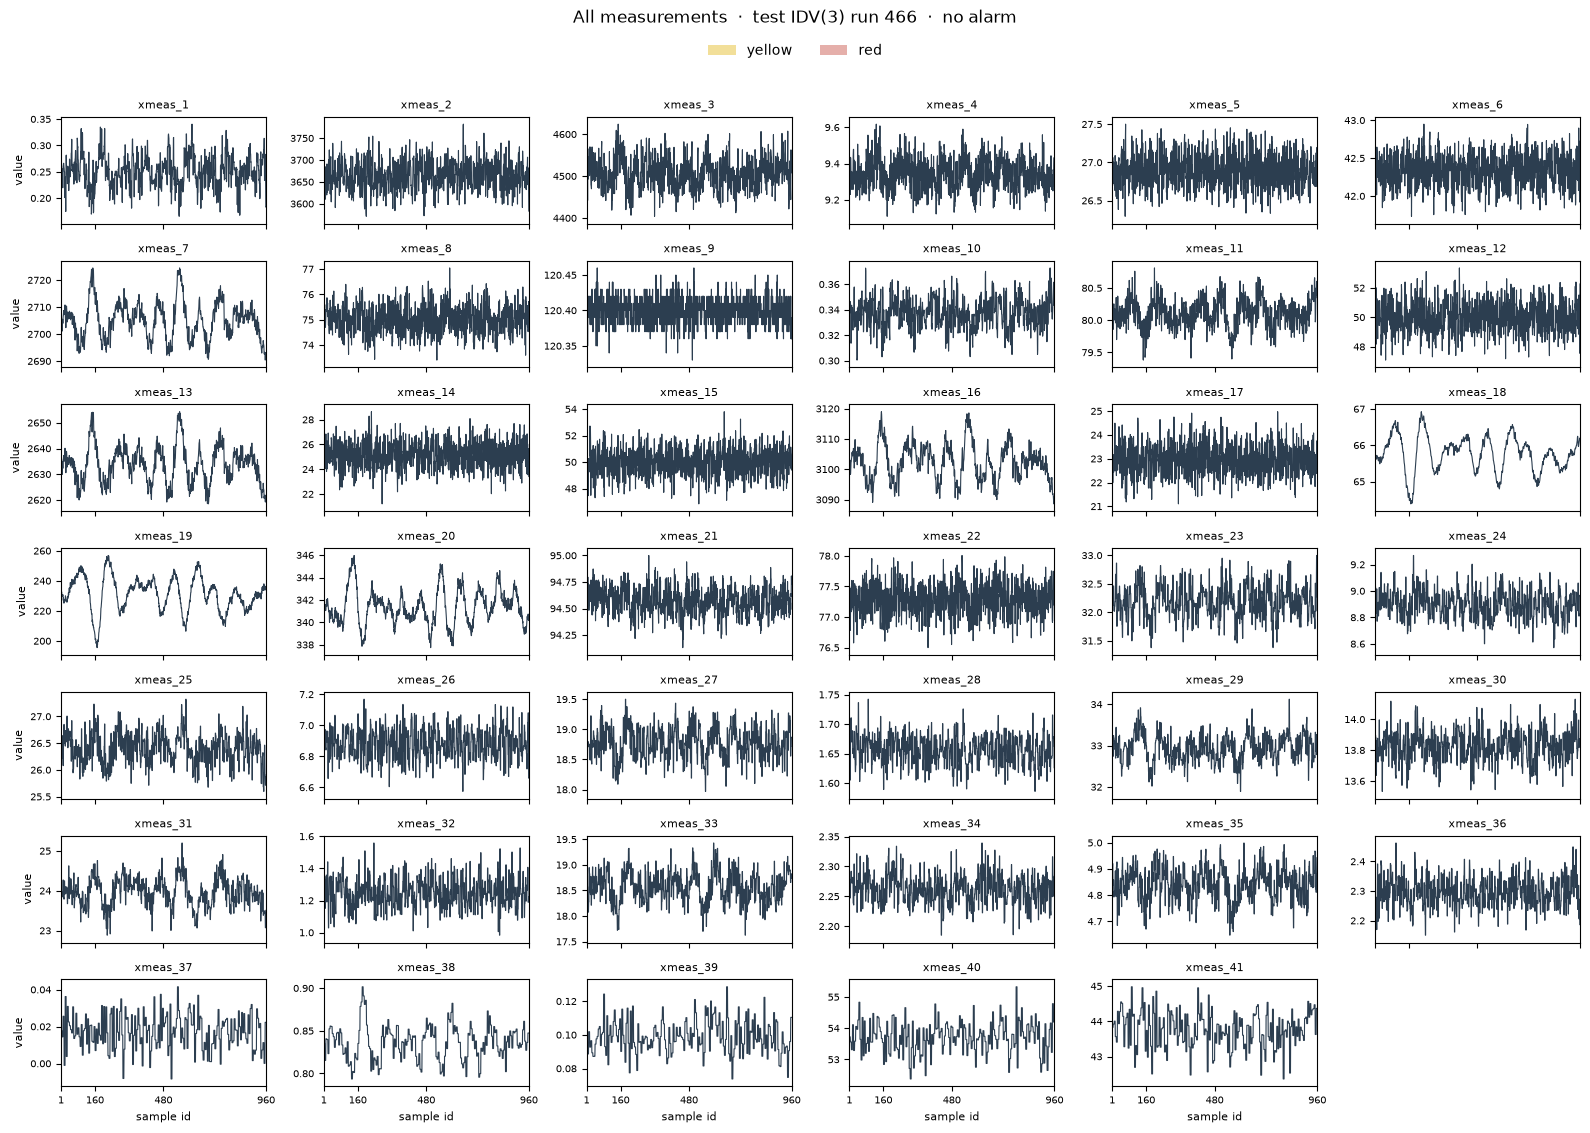

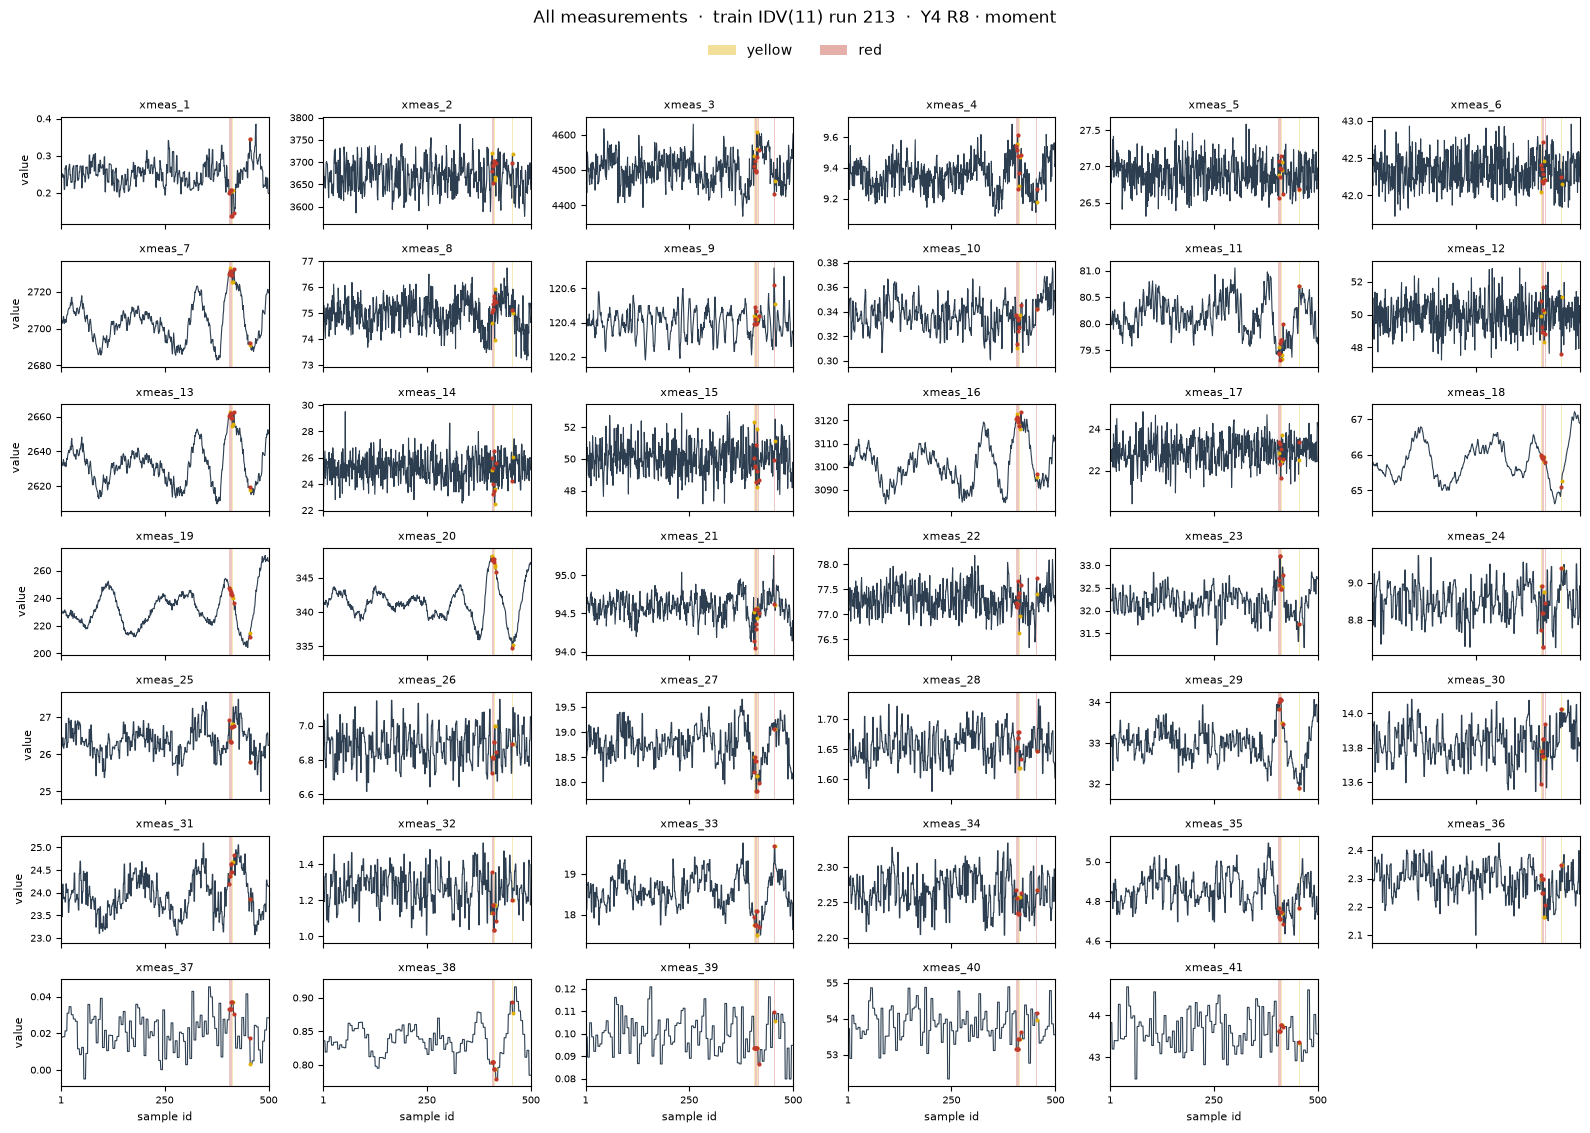

In [68]:
def shade_alarms(ax, spans: list[tuple[float, float, str]], ymax=None) -> None:
    for x0, x1, color in spans:
        ax.axvspan(x0 - 0.5, x1 + 0.5, color=color, alpha=0.28, lw=0)


def run_title(a: dict) -> str:
    n_y = int((a["level"] == 1).sum())
    n_r = int((a["level"] == 2).sum())
    extra = "no alarm" if (n_y + n_r) == 0 else f"Y{n_y} R{n_r}"
    why = top_reason(a)
    if why:
        extra = f"{extra} · {why}"
    return f"{a['source']} IDV({a['faultNumber']}) run {a['simulationRun']}  ·  {extra}"


def set_sample_axis(ax, samples) -> None:
    tmax = int(np.max(samples))
    ax.set_xlim(1, tmax)
    if tmax <= TRAIN_SAMPLES:
        ax.set_xticks([1, 250, tmax])
    else:
        ax.set_xticks([1, 160, 480, 960] if tmax >= 960 else [1, 160, tmax])
    ax.tick_params(labelsize=7)


def pad_ylim(ax, y: np.ndarray) -> None:
    finite = y[np.isfinite(y)]
    if finite.size == 0:
        return
    ymin, ymax = float(finite.min()), float(finite.max())
    pad = 0.08 * (ymax - ymin if ymax > ymin else 1.0)
    ax.set_ylim(ymin - pad, ymax + pad)


ALARM_HANDLES = [
    Patch(facecolor=YELLOW, alpha=0.4, label="yellow"),
    Patch(facecolor=RED, alpha=0.4, label="red"),
]

if len(plotted) > N_PLOT:
    rng = np.random.default_rng(SPLIT_SEED)
    pick = np.sort(rng.choice(len(plotted), size=N_PLOT, replace=False))
    show = [plotted[int(i)] for i in pick]
else:
    show = list(plotted)
meas_names = [c for c in MEAS_COLS if c in SENSOR_COLS]
log.info("plot runs   %s", [run_title(a) for a in show])
log.info("plot meas   %s channels", len(meas_names))

ncols = 6
nrows = int(np.ceil(len(meas_names) / ncols))
for a in show:
    s = a["samples"]
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 1.55 * nrows), sharex=True, squeeze=False)
    for i, name in enumerate(meas_names):
        ax = axes.ravel()[i]
        y = a["X"][:, SENSOR_COLS.index(name)]
        ax.plot(s, y, color="#2C3E50", lw=0.8)
        shade_alarms(ax, a["spans"])
        y_m = a["level"] == 1
        r_m = a["level"] == 2
        if y_m.any():
            ax.scatter(s[y_m], y[y_m], s=8, c=YELLOW, zorder=3, linewidths=0)
        if r_m.any():
            ax.scatter(s[r_m], y[r_m], s=9, c=RED, zorder=4, linewidths=0)
        pad_ylim(ax, y)
        ax.set_title(name, fontsize=8)
        set_sample_axis(ax, s)
        if i % ncols == 0:
            ax.set_ylabel("value", fontsize=8)
        if i >= (nrows - 1) * ncols:
            ax.set_xlabel("sample id", fontsize=8)
    for j in range(len(meas_names), nrows * ncols):
        axes.ravel()[j].axis("off")
    fig.legend(handles=ALARM_HANDLES, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"All measurements  ·  {run_title(a)}", y=1.04, fontsize=12)
    fig.tight_layout()
    plt.show()


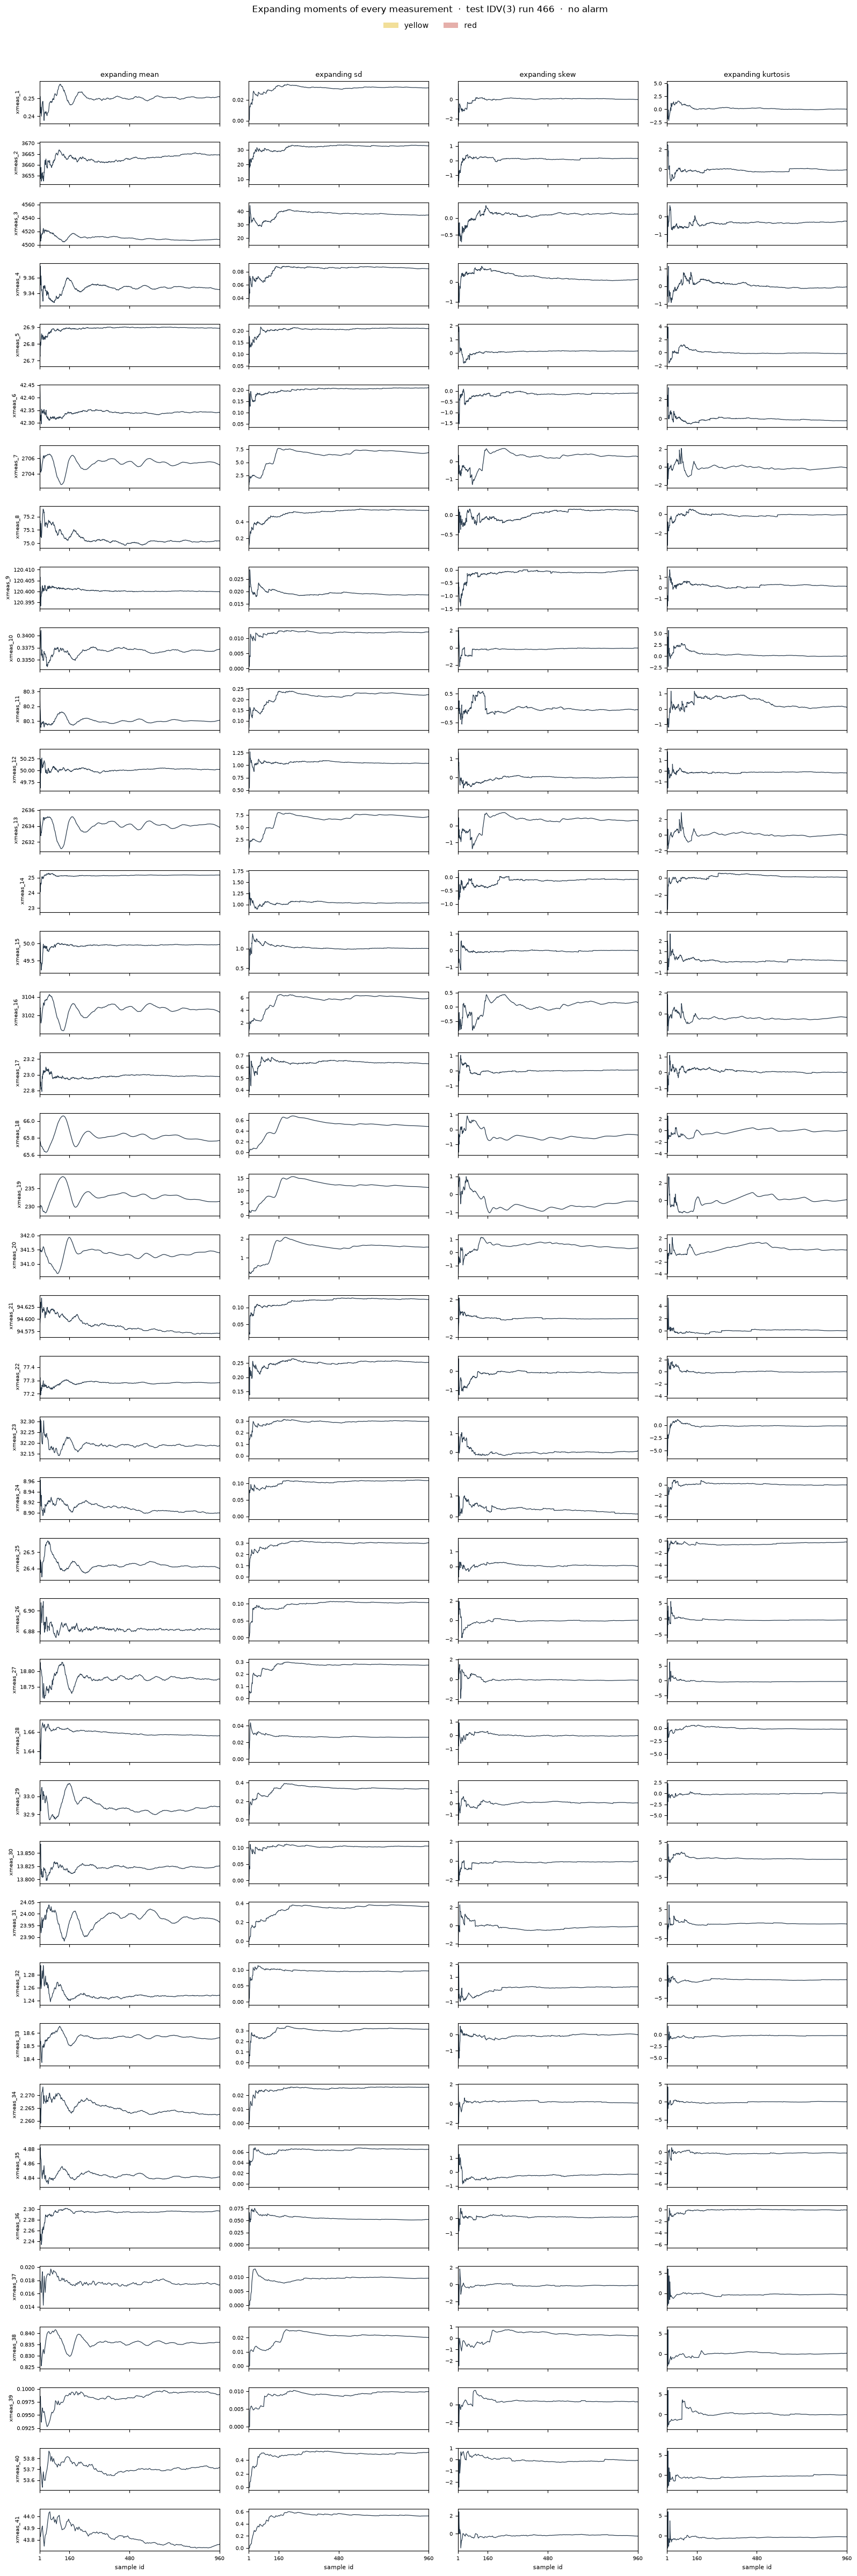

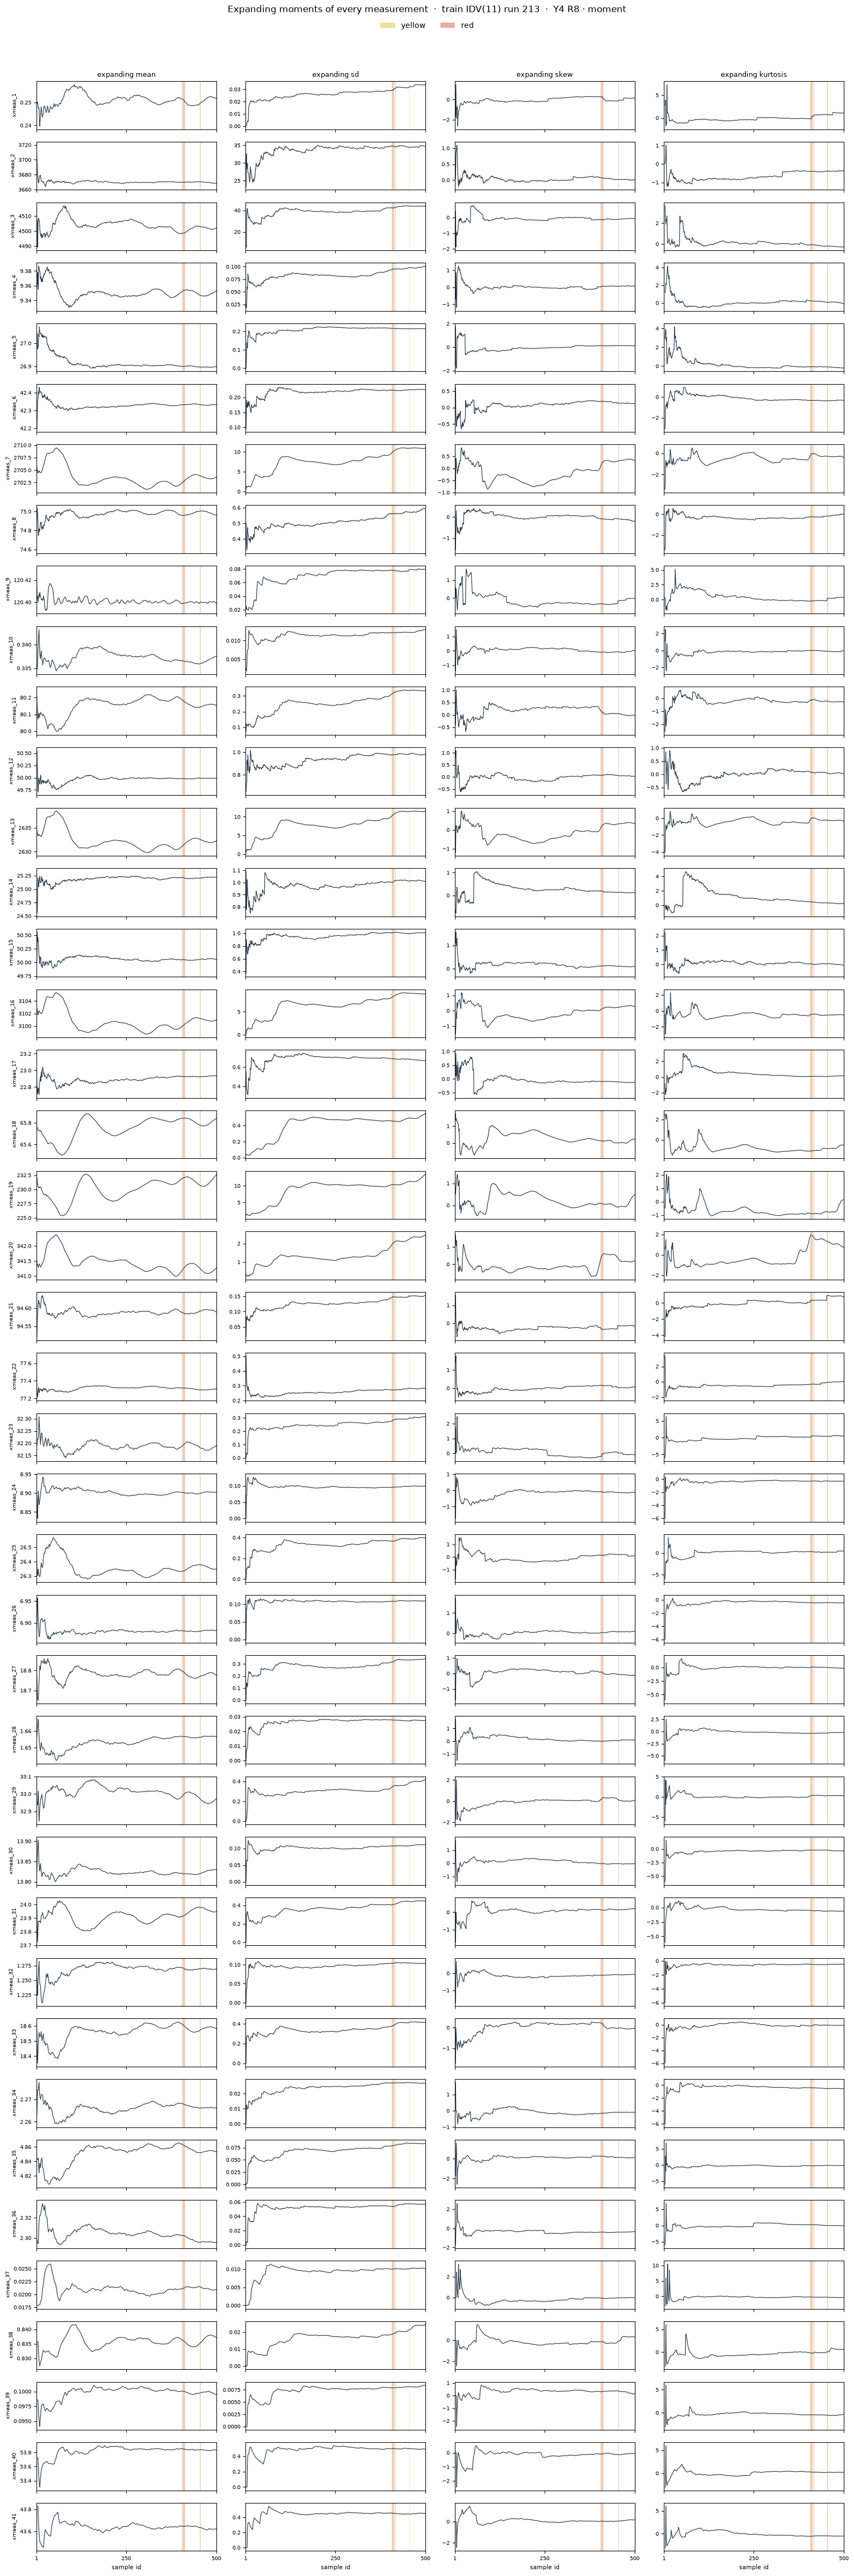

In [69]:
moment_keys = ("mean", "sd", "skew", "kurt")
ylabels = ("expanding mean", "expanding sd", "expanding skew", "expanding kurtosis")

for a in show:
    s = a["samples"]
    fig, axes = plt.subplots(len(meas_names), 4, figsize=(16, 1.15 * len(meas_names)), sharex=True, squeeze=False)
    for i, name in enumerate(meas_names):
        idx = SENSOR_COLS.index(name)
        for j, (key, ylab) in enumerate(zip(moment_keys, ylabels)):
            ax = axes[i, j]
            y = a[key][:, idx]
            ax.plot(s, y, color="#2C3E50", lw=0.9)
            shade_alarms(ax, a["spans"])
            pad_ylim(ax, y)
            set_sample_axis(ax, s)
            if i == 0:
                ax.set_title(ylab, fontsize=9)
            if j == 0:
                ax.set_ylabel(name, fontsize=7)
            if i == len(meas_names) - 1:
                ax.set_xlabel("sample id", fontsize=8)
    fig.legend(handles=ALARM_HANDLES, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.012))
    fig.suptitle(f"Expanding moments of every measurement  ·  {run_title(a)}", y=1.016, fontsize=12)
    fig.tight_layout()
    plt.show()


In [ ]:
for a in show:
    s = a["samples"]
    fig, axes = plt.subplots(len(meas_names), 2, figsize=(14, 1.2 * len(meas_names)), sharex=True, squeeze=False)
    freeze_on = a["freeze"] > 0
    amp_on = a["amp"] > 0
    for i, name in enumerate(meas_names):
        idx = SENSOR_COLS.index(name)
        meas_pos = MEAS_COLS.index(name)
        ax0, ax1 = axes[i, 0], axes[i, 1]

        d = np.r_[np.nan, np.diff(a["X"][:, idx])]
        ax0.plot(s, d, color="#2C3E50", lw=0.75)
        shade_alarms(ax0, a["spans"])
        ax0.axhline(0.0, color="#888888", lw=0.5)
        this_fr = freeze_on & (a["which_fr"] == meas_pos)
        if this_fr.any():
            ax0.scatter(
                s[this_fr],
                d[this_fr],
                s=8,
                c=[RED if v == 2 else YELLOW for v in a["freeze"][this_fr]],
                zorder=3,
                linewidths=0,
            )
        pad_ylim(ax0, d)
        set_sample_axis(ax0, s)
        ax0.set_ylabel(name, fontsize=7)
        if i == 0:
            ax0.set_title("Δx  (freeze = near-zero streak on this channel)", fontsize=9)

        loc = a["local_amp"][:, meas_pos]
        ax1.plot(s, loc, color="#2C3E50", lw=0.85)
        shade_alarms(ax1, a["spans"])
        this_amp = amp_on & (a["which_amp"] == meas_pos)
        if this_amp.any():
            ax1.scatter(
                s[this_amp],
                loc[this_amp],
                s=8,
                c=[RED if v == 2 else YELLOW for v in a["amp"][this_amp]],
                zorder=3,
                linewidths=0,
            )
        pad_ylim(ax1, loc)
        set_sample_axis(ax1, s)
        if i == 0:
            ax1.set_title(f"local amplitude (ptp, window={AMP_WINDOW})", fontsize=9)
        if i == len(meas_names) - 1:
            ax0.set_xlabel("sample id", fontsize=8)
            ax1.set_xlabel("sample id", fontsize=8)

    fig.legend(handles=ALARM_HANDLES, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.012))
    fig.suptitle(f"Differences and amplitude of every measurement  ·  {run_title(a)}", y=1.016, fontsize=12)
    fig.tight_layout()
    plt.show()


## 7. All measurements, 1,000 runs

Two scatters per `xmeas_1…41`: **black** (not faulty) then **red** (faulty), in that order. Same y-scale on each pair. X-axis is sample id.


In [ ]:
XMEAS_COLS = [f"xmeas_{i}" for i in range(1, 42) if f"xmeas_{i}" in SENSOR_COLS]
healthy_pts = runs.loc[runs["fault_status"].astype(str).eq("normal")]
faulty_pts = runs.loc[~runs["fault_status"].astype(str).eq("normal")]
log.info(
    "cloud plot  healthy_rows=%s  faulty_rows=%s  sensors=%s  panels=%s",
    f"{len(healthy_pts):,}",
    f"{len(faulty_pts):,}",
    len(XMEAS_COLS),
    2 * len(XMEAS_COLS),
)

n_panels = 2 * len(XMEAS_COLS)
ncols = 6
nrows = int(np.ceil(n_panels / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 2.35 * nrows), sharex=True)
axes = axes.ravel()
for i, col in enumerate(XMEAS_COLS):
    y_h = healthy_pts[col].to_numpy(np.float64)
    y_f = faulty_pts[col].to_numpy(np.float64)
    finite = np.concatenate([y_h[np.isfinite(y_h)], y_f[np.isfinite(y_f)]])
    if finite.size:
        ymin, ymax = float(finite.min()), float(finite.max())
        pad = 0.04 * (ymax - ymin if ymax > ymin else 1.0)
        ylim = (ymin - pad, ymax + pad)
    else:
        ylim = None
    for k, (pts, color, tag) in enumerate(
        ((healthy_pts, "black", "not faulty"), (faulty_pts, "red", "faulty"))
    ):
        ax = axes[2 * i + k]
        ax.scatter(
            pts["sample"],
            pts[col],
            s=2,
            c=color,
            alpha=0.25,
            linewidths=0,
            rasterized=True,
        )
        ax.set_title(f"{col}  ·  {tag}", fontsize=9)
        ax.tick_params(labelsize=7)
        ax.set_xlim(1, TEST_SAMPLES)
        if ylim is not None:
            ax.set_ylim(*ylim)
        if (2 * i + k) % ncols == 0:
            ax.set_ylabel("value", fontsize=8)
        if (2 * i + k) >= (nrows - 1) * ncols:
            ax.set_xlabel("sample id", fontsize=8)

for j in range(n_panels, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("xmeas 1–41   each sensor: black (not faulty) then red (faulty)   ·   1,000 runs", y=1.01, fontsize=12)
fig.tight_layout()
plt.show()


## 8. Alert histogram by sample window

One bar chart per `xmeas_1…41`. **X** = sample id 1–960 in columns of width **20** (1–20, 21–40, …, 941–960). Each **faulty-run** sample where *this* sensor alerts (`|z|≥4` or outside the IDV(0) min/max) adds 1 to that column. **Y** = how many of those alerts landed in the window.


In [ ]:
XMEAS_COLS = [f"xmeas_{i}" for i in range(1, 42) if f"xmeas_{i}" in SENSOR_COLS]
healthy_pts = runs.loc[runs["fault_status"].astype(str).eq("normal")]
faulty_pts = runs.loc[~runs["fault_status"].astype(str).eq("normal")]
SAMPLE_BIN = 20
sample_edges = np.arange(1, TEST_SAMPLES + 1, SAMPLE_BIN, dtype=int)
if int(sample_edges[-1]) != TEST_SAMPLES + 1:
    sample_edges = np.r_[sample_edges, TEST_SAMPLES + 1]
n_bins = len(sample_edges) - 1

if all(name in globals() for name in ("mu0", "sd0", "lo", "hi")):
    mu_s = pd.Series(mu0, index=SENSOR_COLS)
    sd_s = pd.Series(sd0, index=SENSOR_COLS)
    lo_s = pd.Series(lo, index=SENSOR_COLS)
    hi_s = pd.Series(hi, index=SENSOR_COLS)
    log.info("hist stats  catalog train IDV(0)")
else:
    mu_s = healthy_pts[XMEAS_COLS].mean()
    sd_s = healthy_pts[XMEAS_COLS].std(ddof=1).clip(lower=1e-12)
    lo_s = healthy_pts[XMEAS_COLS].min()
    hi_s = healthy_pts[XMEAS_COLS].max()
    log.info("hist stats  from not-faulty rows in the 1,000-run draw")

log.info(
    "alert hist  faulty_rows=%s  bins=%s  width=%s  sensors=%s",
    f"{len(faulty_pts):,}",
    n_bins,
    SAMPLE_BIN,
    len(XMEAS_COLS),
)

ncols = 6
nrows = int(np.ceil(len(XMEAS_COLS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 2.35 * nrows), sharex=True, sharey=False)
axes = axes.ravel()
fault_samples = faulty_pts["sample"].to_numpy(np.int32)
for i, col in enumerate(XMEAS_COLS):
    ax = axes[i]
    x = faulty_pts[col].to_numpy(np.float64)
    z = np.abs(x - float(mu_s[col])) / float(sd_s[col])
    hit = (x < float(lo_s[col])) | (x > float(hi_s[col])) | (z >= 4.0)
    ids = fault_samples[np.isfinite(x) & hit]
    counts, _ = np.histogram(ids, bins=sample_edges)
    ax.bar(
        sample_edges[:-1],
        counts,
        width=SAMPLE_BIN,
        align="edge",
        color="#D4A574",
        edgecolor="black",
        linewidth=0.4,
    )
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.set_xlim(1, TEST_SAMPLES)
    ax.set_xticks([1, 160, 500, 960])
    if i % ncols == 0:
        ax.set_ylabel("alerts", fontsize=8)
    if i >= (nrows - 1) * ncols:
        ax.set_xlabel("sample id", fontsize=8)

for j in range(len(XMEAS_COLS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    f"xmeas 1–41   alerts on faulty runs   columns = sample id {SAMPLE_BIN}   (1–20, 21–40, …)   ·   1,000 runs",
    y=1.02,
    fontsize=12,
)
fig.tight_layout()
plt.show()


## 9. One random run on the 1,000-run cloud

Two panels per `xmeas_1…41` (**82 plots**): **black** (not faulty) then **red** (faulty), side by side, same y-scale. The **blue line** is one random run and is drawn only on the matching class. Yellow / red bands and dots are **v5 alarms** on that run (not mixed with catalog methods).


In [ ]:
XMEAS_COLS = [f"xmeas_{i}" for i in range(1, 42) if f"xmeas_{i}" in SENSOR_COLS]
healthy_pts = runs.loc[runs["fault_status"].astype(str).eq("normal")]
faulty_pts = runs.loc[~runs["fault_status"].astype(str).eq("normal")]

rng = np.random.default_rng(SPLIT_SEED + 17)
pick = keys.iloc[int(rng.integers(0, len(keys)))]
src, fn, rn = str(pick["source"]), int(pick["faultNumber"]), int(pick["simulationRun"])
g = runs.loc[
    runs["source"].astype(str).eq(src)
    & runs["faultNumber"].astype(int).eq(fn)
    & runs["simulationRun"].astype(int).eq(rn)
]
trace = analyze_run(g)
s = trace["samples"]
status = str(trace["fault_status"])
is_faulty = status != "normal"
tag = "faulty" if is_faulty else "not faulty"
n_y = int((trace["level"] == 1).sum())
n_r = int((trace["level"] == 2).sum())
log.info(
    "overlay run  %s IDV(%s) run %s  %s  Y%s R%s  panels=%s",
    src,
    fn,
    rn,
    tag,
    n_y,
    n_r,
    2 * len(XMEAS_COLS),
)

n_panels = 2 * len(XMEAS_COLS)
ncols = 6
nrows = int(np.ceil(n_panels / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 2.45 * nrows), sharex=True)
axes = axes.ravel()
y_m = trace["level"] == 1
r_m = trace["level"] == 2
for i, col in enumerate(XMEAS_COLS):
    y_run = trace["X"][:, SENSOR_COLS.index(col)]
    y_h = healthy_pts[col].to_numpy(np.float64)
    y_f = faulty_pts[col].to_numpy(np.float64)
    finite = np.concatenate(
        [y_h[np.isfinite(y_h)], y_f[np.isfinite(y_f)], y_run[np.isfinite(y_run)]]
    )
    if finite.size:
        ymin, ymax = float(finite.min()), float(finite.max())
        pad = 0.06 * (ymax - ymin if ymax > ymin else 1.0)
        ylim = (ymin - pad, ymax + pad)
    else:
        ylim = None
    for k, (pts, color, ctag) in enumerate(
        ((healthy_pts, "black", "not faulty"), (faulty_pts, "red", "faulty"))
    ):
        ax = axes[2 * i + k]
        ax.scatter(
            pts["sample"],
            pts[col],
            s=2,
            c=color,
            alpha=0.18,
            linewidths=0,
            rasterized=True,
            zorder=1,
        )
        match = (ctag == "faulty") == is_faulty
        if match:
            for x0, x1, acolor in trace["spans"]:
                ax.axvspan(x0 - 0.5, x1 + 0.5, color=acolor, alpha=0.28, lw=0, zorder=2)
            ax.plot(s, y_run, color="#1F6FEB", lw=1.35, zorder=3, solid_capstyle="round")
            if y_m.any():
                ax.scatter(s[y_m], y_run[y_m], s=14, c=YELLOW, zorder=4, linewidths=0)
            if r_m.any():
                ax.scatter(s[r_m], y_run[r_m], s=16, c=RED, zorder=5, linewidths=0)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.set_title(f"{col}  ·  {ctag}", fontsize=9)
        ax.tick_params(labelsize=7)
        ax.set_xlim(1, TEST_SAMPLES)
        if (2 * i + k) % ncols == 0:
            ax.set_ylabel("value", fontsize=8)
        if (2 * i + k) >= (nrows - 1) * ncols:
            ax.set_xlabel("sample id", fontsize=8)

for j in range(n_panels, len(axes)):
    axes[j].set_visible(False)

from matplotlib.lines import Line2D

fig.legend(
    handles=[
        Line2D([0], [0], color="black", marker="o", ls="none", markersize=6, label="not faulty cloud"),
        Line2D([0], [0], color="red", marker="o", ls="none", markersize=6, label="faulty cloud"),
        Line2D([0], [0], color="#1F6FEB", lw=2, label=f"this run  {src} IDV({fn}) #{rn}  ({tag})"),
        Line2D([0], [0], color=YELLOW, marker="o", ls="none", markersize=7, label="yellow alarm"),
        Line2D([0], [0], color=RED, marker="o", ls="none", markersize=7, label="red alarm"),
    ],
    loc="upper center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)
fig.suptitle(
    f"xmeas 1–41   black then red   ·   blue run on {tag}   ·   v5 yellow/red   ·   {src} IDV({fn}) run {rn}",
    y=1.04,
    fontsize=12,
)
fig.tight_layout()
plt.show()


## 10. What this is (and is not)

- **Is:** online, per-run detection from expanding moments, near-zero **difference streaks** (stuck sensor), and **local amplitude growth**. Gates start strict and ease with sample index. No CSV labels in the decision.
- **TPR/FPR** is a post-hoc read of those decisions against CSV `fault_status`: faulty should have ≥1 yellow/red event; normal should have 0. Change `N_RUNS` (and re-run from the top) to score more of the 21,000 keys.
- **Catalog methods** still fit train IDV(0) (`out_of_range`, `zscore_4sd`, `persist_4sd`, `nb`, `fda`). **`_self`** versions of the first three use only this run, one tick at a time (`x_t` vs `{1,…,t−1}`), like v5. `nb`/`fda` cannot: they need labels. None of these are mixed into the v5 gates.
- **Plots** are `N_PLOT` random runs (default 2) with **every `xmeas_*` channel**. Hard IDVs (3, 9, 15, …) often miss — that is the honest output, not a plotting artifact.
- **All-measurement cloud:** 82 panels of `xmeas_1…41` (black = not faulty, then red = faulty). §9 overlays one random run as a blue line on the matching class only.
- **Alert histogram:** each `xmeas_*` is a bar chart of sample-id windows (width 20). Height = how many faulty-run alerts (`|z|≥4` or out of range) fell in that window.
- **Run overlay:** one random run from the 1,000 is drawn in **blue** on the matching black/red cloud, with that run’s v5 yellow/red alarms, for every `xmeas_*`.
